# Supply Chain Intelligence Hub

This notebook implements an end\-to\-end workflow for Supply Chain Management It is designed to be robust to arbitrary column names and will automatically detect relevant fields when possible\. The workflow covers data loading, cleaning, feature engineering, exploratory analysis, KPI computation, machine learning, insights, and an export suitable for Power BI\.

In [5]:
# Imports and setup
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# scikit-learn
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Excel engine
import openpyxl

# Plot style
sns.set(style='whitegrid')

# Load dataset
file_path = 'supply_chain_data.csv'
df = pd.read_csv(file_path, low_memory=False)

# Basic inspection
print('Dataset shape:', df.shape)
print('\nColumns:', list(df.columns))
print('\nDtypes:\n', df.dtypes)

# Missing values
missing_per_col = df.isna().sum().sort_values(ascending=False)
print('\nMissing values per column:\n', missing_per_col)
print('\nTotal missing values:', int(missing_per_col.sum()))

# Duplicates
dup_count = int(df.duplicated().sum())
print('\nDuplicate rows:', dup_count)

# Descriptive statistics
num_desc = df.select_dtypes(include=[np.number]).describe().T
obj_desc = df.select_dtypes(exclude=[np.number]).describe(include='all').T
print('\nNumeric columns descriptive stats:\n', num_desc)
print('\nObject columns descriptive stats:\n', obj_desc)

# Data quality summary
n_rows = len(df)
completeness = (1 - missing_per_col / n_rows).round(3) if n_rows > 0 else pd.Series()

# dtype issues heuristic: columns with all NaNs after try-convert numeric/date
dtype_issues = []
for col in df.columns:
    ser = df[col]
    if ser.dtype == 'O':
        # try numeric
        num_try = pd.to_numeric(ser, errors='coerce')
        dt_try = pd.to_datetime(ser, errors='coerce', infer_datetime_format=True)
        if num_try.notna().sum() > 0 or dt_try.notna().sum() > 0:
            dtype_issues.append(col)

# potential key columns: low missing, high uniqueness
potential_keys = []
for col in df.columns:
    if df[col].isna().mean() < 0.05:
        uniq_ratio = df[col].nunique(dropna=True) / max(1, n_rows)
        if 0.5 < uniq_ratio <= 1.0:
            potential_keys.append(col)

# high-cardinality columns
high_card_cols = []
for col in df.columns:
    uniq = df[col].nunique(dropna=True)
    if n_rows > 0 and uniq / n_rows > 0.5 and uniq > 50:
        high_card_cols.append(col)

print('\nConcise data quality summary:')
print('Completeness (%) by column:\n', (completeness*100).astype('float').round(1) if len(completeness)>0 else 'N/A')
print('Columns with potential dtype coercion opportunities:', dtype_issues)
print('Potential key columns (high uniqueness, low missing):', potential_keys)
print('High-cardinality columns:', high_card_cols)

# Keep key objects available in notebook
missing_per_col, num_desc, obj_desc

Dataset shape: (100, 24)

Columns: ['Product type', 'SKU', 'Price', 'Availability', 'Number of products sold', 'Revenue generated', 'Customer demographics', 'Stock levels', 'Lead times', 'Order quantities', 'Shipping times', 'Shipping carriers', 'Shipping costs', 'Supplier name', 'Location', 'Lead time', 'Production volumes', 'Manufacturing lead time', 'Manufacturing costs', 'Inspection results', 'Defect rates', 'Transportation modes', 'Routes', 'Costs']

Dtypes:
 Product type                object
SKU                         object
Price                      float64
Availability                 int64
Number of products sold      int64
Revenue generated          float64
Customer demographics       object
Stock levels                 int64
Lead times                   int64
Order quantities             int64
Shipping times               int64
Shipping carriers           object
Shipping costs             float64
Supplier name               object
Location                    object
Lead t

(Product type               0
 SKU                        0
 Price                      0
 Availability               0
 Number of products sold    0
 Revenue generated          0
 Customer demographics      0
 Stock levels               0
 Lead times                 0
 Order quantities           0
 Shipping times             0
 Shipping carriers          0
 Shipping costs             0
 Supplier name              0
 Location                   0
 Lead time                  0
 Production volumes         0
 Manufacturing lead time    0
 Manufacturing costs        0
 Inspection results         0
 Defect rates               0
 Transportation modes       0
 Routes                     0
 Costs                      0
 dtype: int64,
                          count         mean          std          min  \
 Price                    100.0    49.462461    31.168193     1.699976   
 Availability             100.0    48.400000    30.743317     1.000000   
 Number of products sold  100.0   460.99000

## Step 2: Data cleaning and validation

In [7]:
# Remove duplicates
initial_rows = len(df)
df = df.drop_duplicates().copy()
removed_dups = initial_rows - len(df)

# Dynamic type coercion heuristics
coercion_report = []

def should_parse_datetime(col_name: str) -> bool:
    name = col_name.lower()
    keywords = ['date', 'time', 'timestamp', 'dt', 'delivery', 'ship', 'lead']
    return any(k in name for k in keywords)

# Attempt to coerce object columns to numeric or datetime when sensible
for col in df.columns:
    ser = df[col]
    if ser.dtype == 'O':
        coerced = False
        # Try numeric if looks numeric-like
        num_try = pd.to_numeric(ser.str.replace(',', '').str.extract(r'([-+]?[0-9]*\.?[0-9]+)')[0] if ser.str.contains(r'[0-9]', regex=True).any() else ser, errors='coerce')
        if num_try.notna().sum() > 0 and num_try.notna().sum() >= (0.3 * len(ser)):
            df[col] = num_try
            coercion_report.append(f"Converted {col} to numeric based on heuristic")
            coerced = True
        # Try datetime if name suggests time-like and not already coerced
        if not coerced and should_parse_datetime(col):
            dt_try = pd.to_datetime(ser, errors='coerce', infer_datetime_format=True)
            if dt_try.notna().sum() > 0:
                df[col] = dt_try
                coercion_report.append(f"Converted {col} to datetime based on name heuristic")
                coerced = True

# Re-identify numeric cols
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
nonfinite_counts = {}
for col in numeric_cols:
    ser = df[col]
    nonfinite_counts[col] = int(np.isfinite(ser).sum() != ser.shape[0])

# Recompute missing values
missing_after = df.isna().sum().sort_values(ascending=False)

# Outlier detection using IQR
outlier_flags = pd.DataFrame(index=df.index)
outlier_counts = {}
for col in numeric_cols:
    vals = df[col].astype(float)
    Q1 = vals.quantile(0.25)
    Q3 = vals.quantile(0.75)
    IQR = Q3 - Q1
    if pd.isna(IQR) or IQR == 0:
        outlier_flags[col] = False
        outlier_counts[col] = 0
        continue
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    flags = (vals < lower) | (vals > upper)
    outlier_flags[col] = flags
    outlier_counts[col] = int(flags.sum())

# Create cleaned dataframe copy (leave numeric NaNs as-is)
df_clean = df.copy()

# Cleaning report
print('Data cleaning report:')
print(f'- Duplicates removed: {removed_dups}')
print(f'- Numeric columns detected: {len(numeric_cols)} -> {numeric_cols}')
print(f'- Columns with non-finite values (any presence marked as 1): {nonfinite_counts}')
print(f'- Conversions performed ({len(coercion_report)}):')
for msg in coercion_report:
    print('  *', msg)
print('\nMissing values after coercion:\n', missing_after)
print('\nOutlier counts per numeric column:\n', pd.Series(outlier_counts))

# Keep in scope
outlier_flags, outlier_counts, df_clean, numeric_cols

Data cleaning report:
- Duplicates removed: 0
- Numeric columns detected: 17 -> ['SKU', 'Price', 'Availability', 'Number of products sold', 'Revenue generated', 'Stock levels', 'Lead times', 'Order quantities', 'Shipping times', 'Shipping costs', 'Supplier name', 'Lead time', 'Production volumes', 'Manufacturing lead time', 'Manufacturing costs', 'Defect rates', 'Costs']
- Columns with non-finite values (any presence marked as 1): {'SKU': 0, 'Price': 0, 'Availability': 0, 'Number of products sold': 0, 'Revenue generated': 0, 'Stock levels': 0, 'Lead times': 0, 'Order quantities': 0, 'Shipping times': 0, 'Shipping costs': 0, 'Supplier name': 0, 'Lead time': 0, 'Production volumes': 0, 'Manufacturing lead time': 0, 'Manufacturing costs': 0, 'Defect rates': 0, 'Costs': 0}
- Conversions performed (2):
  * Converted SKU to numeric based on heuristic
  * Converted Supplier name to numeric based on heuristic

Missing values after coercion:
 Product type               0
SKU                    

(      SKU  Price  Availability  Number of products sold  Revenue generated  \
 0   False  False         False                    False              False   
 1   False  False         False                    False              False   
 2   False  False         False                    False              False   
 3   False  False         False                    False              False   
 4   False  False         False                    False              False   
 ..    ...    ...           ...                      ...                ...   
 95  False  False         False                    False              False   
 96  False  False         False                    False              False   
 97  False  False         False                    False              False   
 98  False  False         False                    False              False   
 99  False  False         False                    False              False   
 
     Stock levels  Lead times  Order quantities  S

## Step 3: Feature engineering and helper functions

We will harden feature engineering and modeling for robustness: restrict fuzzy detection to numeric bases for scores, guard against division by zero, compute engineered features only when bases exist, handle case\-insensitive shipping cost detection, compute categorical bands only from numeric columns with valid quantiles, create an imputed df\_ml for ML, and wrap ML steps with graceful skips if prerequisites are missing\. Finally, we will add a smoke test to validate the pipeline\.

In [9]:
# Robust feature engineering with numeric-only bases and guards
import re

KEYWORDS = {
    'revenue': ['revenue', 'sales', 'amount', 'turnover'],
    'units': ['units', 'quantity', 'qty', 'sold', 'volume', 'order quantities', 'number of products sold'],
    'stock': ['stock', 'inventory', 'on_hand', 'on hand', 'stock levels'],
    'cost': ['cost', 'expense', 'cogs', 'manufacturing costs', 'shipping costs', 'costs'],
    'supplier': ['supplier', 'vendor'],
    'lead_time': ['lead time', 'lead times', 'manufacturing lead time'],
    'ship_time': ['shipping times', 'transit', 'delivery time'],
    'defect': ['defect rates']
}

# Detect columns by simple keyword matching (case-insensitive)
def detect_columns(cols):
    cols_l = [c.lower() for c in cols]
    mapping = {k: [] for k in KEYWORDS}
    for i, c in enumerate(cols_l):
        for key, kws in KEYWORDS.items():
            if any(kw in c for kw in kws):
                mapping[key].append(list(df_clean.columns)[i])
    return mapping

col_map = detect_columns(df_clean.columns)
print('Detected columns by category:', col_map)

# Helpers
scaler01 = MinMaxScaler()

def minmax_series(s: pd.Series):
    if s is None or s.dropna().nunique() <= 1:
        return pd.Series(np.nan, index=s.index)
    vals = s.astype(float)
    lo, hi = vals.min(), vals.max()
    if pd.isna(lo) or pd.isna(hi) or hi == lo:
        return pd.Series(np.nan, index=s.index)
    return (vals - lo) / (hi - lo)

# First numeric column from candidates
numeric_cols_all = df_clean.select_dtypes(include=[np.number]).columns.tolist()

def first_numeric(candidates):
    for c in candidates:
        if c in numeric_cols_all:
            return c
    return None

# Engineered revenue
revenue_cols = [c for c in col_map.get('revenue', []) if c in numeric_cols_all]
unit_candidates = col_map.get('units', [])
price_cols = [c for c in df_clean.columns if 'price' in c.lower() and c in numeric_cols_all]

engineered_revenue_col = None
if len(revenue_cols) == 0 and len(price_cols) > 0 and len(unit_candidates) > 0:
    units_col = first_numeric(unit_candidates)
    if units_col is not None:
        price_col = price_cols[0]
        df_clean['Engineered_Revenue'] = df_clean[price_col].astype(float) * df_clean[units_col].astype(float)
        engineered_revenue_col = 'Engineered_Revenue'
        print(f"Engineered revenue as {price_col} * {units_col} -> Engineered_Revenue")
    else:
        print('Skipped Engineered_Revenue: no numeric units column found')
else:
    engineered_revenue_col = revenue_cols[0] if len(revenue_cols)>0 else None

# Revenue per Unit
if engineered_revenue_col is not None:
    units_col = first_numeric(unit_candidates)
    if units_col is not None:
        denom = df_clean[units_col].replace(0, np.nan).astype(float)
        df_clean['Revenue_per_Unit'] = (df_clean[engineered_revenue_col].astype(float) / denom).replace([np.inf, -np.inf], np.nan)
        print('Created Revenue_per_Unit')
    else:
        print('Skipped Revenue_per_Unit: no numeric units column found')
else:
    print('Skipped Revenue_per_Unit: no revenue base available')

# Inventory Health Score
stock_cols = [c for c in col_map.get('stock', []) if c in numeric_cols_all]
lead_cols = [c for c in col_map.get('lead_time', []) if c in numeric_cols_all]
if len(stock_cols)>0 and first_numeric(unit_candidates) is not None:
    stock_col = stock_cols[0]
    units_col = first_numeric(unit_candidates)
    velocity = minmax_series(df_clean[units_col])
    denom = df_clean[units_col].replace(0, np.nan)
    ratio = (df_clean[stock_col] / denom).replace([np.inf, -np.inf], np.nan)
    adequacy = 1 - minmax_series(ratio)
    safety = None
    if len(lead_cols)>0:
        safety = 1 - minmax_series(df_clean[lead_cols[0]])
    if safety is None:
        inv_score01 = (0.6 * adequacy)
    else:
        inv_score01 = (0.6 * adequacy) + (0.4 * safety)
    df_clean['Inventory_Health_Score'] = (inv_score01 * 100).clip(0, 100)
    print('Created Inventory_Health_Score')
else:
    print('Skipped Inventory_Health_Score: missing stock or units numeric bases')

# Supplier Performance Score
supplier_cols = col_map.get('supplier', [])
# numeric-only bases
lead_base = first_numeric(lead_cols)
# defect: restrict to numeric candidates only (e.g., Defect rates)
defect_cols = [c for c in col_map.get('defect', []) if c in numeric_cols_all]
defect_base = first_numeric(defect_cols)
ship_time_candidates = [c for c in col_map.get('ship_time', []) if c in numeric_cols_all]
ship_base = first_numeric(ship_time_candidates)

parts = []
if lead_base is not None:
    parts.append(1 - minmax_series(df_clean[lead_base]))
if defect_base is not None:
    parts.append(1 - minmax_series(df_clean[defect_base]))
if ship_base is not None:
    parts.append(1 - minmax_series(df_clean[ship_base]))

if len(parts) > 0:
    score01 = sum(parts) / len(parts)
    df_clean['Supplier_Performance_Score'] = (score01 * 100).clip(0, 100)
    print('Created Supplier_Performance_Score')
else:
    print('Skipped Supplier_Performance_Score: no numeric bases available')

# Logistics Efficiency Score
# Detect shipping time and shipping cost columns robustly (case-insensitive)
ship_time_base = first_numeric([c for c in df_clean.columns if 'ship' in c.lower() and c in numeric_cols_all])
ship_cost_candidates = [c for c in df_clean.columns if ('ship' in c.lower() and 'cost' in c.lower()) and c in numeric_cols_all]
ship_cost_base = first_numeric(ship_cost_candidates)

parts = []
if ship_time_base is not None:
    parts.append(1 - minmax_series(df_clean[ship_time_base]))
if ship_cost_base is not None:
    parts.append(1 - minmax_series(df_clean[ship_cost_base]))

if len(parts) > 0:
    score01 = sum(parts) / len(parts)
    df_clean['Logistics_Efficiency_Score'] = (score01 * 100).clip(0, 100)
    print('Created Logistics_Efficiency_Score')
else:
    print('Skipped Logistics_Efficiency_Score: no numeric shipping time/cost bases')

# Cost Efficiency Score: inverse of cost per unit
cost_cols = [c for c in col_map.get('cost', []) if c in numeric_cols_all]
if len(cost_cols)>0 and first_numeric(unit_candidates) is not None:
    units_col = first_numeric(unit_candidates)
    # pick the most generic total cost if present, else first
    pick = None
    for name in ['costs', 'total cost', 'total costs']:
        for c in cost_cols:
            if c.lower() == name:
                pick = c
                break
        if pick:
            break
    if pick is None:
        pick = cost_cols[0]
    cpu = (df_clean[pick].astype(float) / df_clean[units_col].replace(0, np.nan).astype(float)).replace([np.inf, -np.inf], np.nan)
    inv_cpu = 1 - minmax_series(cpu)
    df_clean['Cost_Efficiency_Score'] = (inv_cpu * 100).clip(0, 100)
    print('Created Cost_Efficiency_Score')
else:
    print('Skipped Cost_Efficiency_Score: missing cost or units numeric bases')

# Categorical bands with guards

def safe_quantile_bands(series, labels):
    if series is None or series.dropna().nunique() < 2:
        return None
    q = series.quantile([0.33, 0.66])
    if q.isna().any():
        return None
    def lab(x):
        if pd.isna(x):
            return np.nan
        if x <= q.iloc[0]:
            return labels[0]
        if x <= q.iloc[1]:
            return labels[1]
        return labels[2]
    return series.apply(lab)

# Defect category
if defect_base is not None:
    bands = safe_quantile_bands(df_clean[defect_base], ['Low', 'Medium', 'High'])
    if bands is not None:
        df_clean['Defect_Category'] = bands
        print('Created Defect_Category')
    else:
        print('Skipped Defect_Category: insufficient variability or invalid quantiles')

# Stock category
if len(stock_cols)>0:
    bands = safe_quantile_bands(df_clean[stock_cols[0]], ['Low', 'Medium', 'High'])
    if bands is not None:
        df_clean['Stock_Category'] = bands
        print('Created Stock_Category')
    else:
        print('Skipped Stock_Category: insufficient variability or invalid quantiles')

# Lead time category
if lead_base is not None:
    bands = safe_quantile_bands(df_clean[lead_base], ['Short', 'Medium', 'Long'])
    if bands is not None:
        df_clean['Lead_Time_Category'] = bands
        print('Created Lead_Time_Category')
    else:
        print('Skipped Lead_Time_Category: insufficient variability or invalid quantiles')

# Shipping time category
if ship_time_base is not None:
    bands = safe_quantile_bands(df_clean[ship_time_base], ['Fast', 'Standard', 'Slow'])
    if bands is not None:
        df_clean['Shipping_Time_Category'] = bands
        print('Created Shipping_Time_Category')
    else:
        print('Skipped Shipping_Time_Category: insufficient variability or invalid quantiles')

# Preview engineered columns
df_clean

Detected columns by category: {'revenue': ['Revenue generated'], 'units': ['Number of products sold', 'Order quantities', 'Production volumes'], 'stock': ['Stock levels'], 'cost': ['Shipping costs', 'Manufacturing costs', 'Costs'], 'supplier': ['Supplier name'], 'lead_time': ['Lead times', 'Lead time', 'Manufacturing lead time'], 'ship_time': ['Shipping times'], 'defect': ['Defect rates']}
Created Revenue_per_Unit
Created Inventory_Health_Score
Created Supplier_Performance_Score
Created Logistics_Efficiency_Score
Created Cost_Efficiency_Score
Created Defect_Category
Created Stock_Category
Created Lead_Time_Category
Created Shipping_Time_Category


,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Costs,Revenue_per_Unit,Inventory_Health_Score,Supplier_Performance_Score,Logistics_Efficiency_Score,Cost_Efficiency_Score,Defect_Category,Stock_Category,Lead_Time_Category,Shipping_Time_Category
0,haircare,0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,187.752075,10.800495,90.604357,80.584644,72.437115,99.669696,Low,Medium,Short,Fast
1,skincare,1,14.843523,95,736,7460.900065,Female,53,30,37,...,503.065579,10.137092,58.884993,30.206703,45.640236,98.331546,High,Medium,Long,Fast
2,haircare,2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,141.920282,1197.218703,85.650723,55.047779,54.960750,47.544354,High,Low,Short,Fast
3,skincare,3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,254.776159,93.576342,79.157565,35.659796,68.206657,91.226800,High,Low,Medium,Standard
4,skincare,4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,923.440632,3.084392,97.152494,50.592565,44.977447,97.209908,High,Low,Short,Slow
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,haircare,95,77.903927,65,672,7386.363944,Unknown,15,14,26,...,778.864241,10.991613,81.723343,47.351164,12.842620,96.915673,Low,Low,Medium,Slow
96,cosmetics,96,24.423131,29,324,7698.424766,Non-binary,67,2,32,...,188.742141,23.760570,95.418778,65.339286,64.554933,98.632209,High,High,Short,Fast
97,haircare,97,3.526111,56,62,4370.916580,Male,46,19,4,...,540.132423,70.498655,63.684380,26.935537,16.910960,74.426625,High,Medium,Medium,Slow
98,skincare,98,19.754605,43,913,8525.952560,Female,53,1,27,...,882.198864,9.338393,99.101155,58.203698,64.444258,97.489632,Medium,Medium,Short,Standard


## Step 4: ML\-ready dataset \(imputation\) and guarded ML tasks

In [11]:
# Create ML-ready copy with numeric imputation
from sklearn.impute import SimpleImputer

# Work on a copy to keep df_clean unchanged for EDA
df_ml = df_clean.copy()

# Impute numeric columns with median
num_cols_ml = df_ml.select_dtypes(include=[np.number]).columns.tolist()
if len(num_cols_ml) > 0:
    imputer = SimpleImputer(strategy='median')
    df_ml[num_cols_ml] = imputer.fit_transform(df_ml[num_cols_ml])
    print(f"Imputed numeric columns for ML: {len(num_cols_ml)} columns")
else:
    print('Skipped imputation: no numeric columns found in df_ml')

# Guarded ML Section 1: Product Segmentation using KMeans on selected features
seg_features_candidates = [
    'Price',
    'Revenue_per_Unit',
    'Inventory_Health_Score',
    'Cost_Efficiency_Score',
]
seg_features = [c for c in seg_features_candidates if c in df_ml.columns and df_ml[c].dtype != 'O']

try:
    if len(seg_features) >= 2 and df_ml[seg_features].dropna().shape[0] >= 2:
        X = df_ml[seg_features].astype(float)
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        # Choose small k for stability
        k = 3
        km = KMeans(n_clusters=k, n_init=10, random_state=42)
        df_ml['Segment'] = km.fit_predict(X_scaled)
        print(f"Product Segmentation executed with features: {seg_features}")
    else:
        print('Skipped Product Segmentation: insufficient numeric features or rows')
except Exception as e:
    print(f"Skipped Product Segmentation due to error: {e}")

# Guarded ML Section 2: Supplier Risk Scoring using PCA + KMeans on supplier-related metrics
supplier_features_candidates = [
    'Supplier_Performance_Score',
    'Lead times' if 'Lead times' in df_ml.columns else None,
    'Defect rates' if 'Defect rates' in df_ml.columns else None,
    'Shipping times' if 'Shipping times' in df_ml.columns else None,
]
supplier_features = [c for c in supplier_features_candidates if c is not None and c in df_ml.columns and df_ml[c].dtype != 'O']

try:
    if len(supplier_features) >= 2 and df_ml[supplier_features].dropna().shape[0] >= 2:
        X = df_ml[supplier_features].astype(float)
        X_scaled = StandardScaler().fit_transform(X)
        # PCA to 2 components when possible
        n_comp = min(2, X_scaled.shape[1])
        X_pca = PCA(n_components=n_comp, random_state=42).fit_transform(X_scaled)
        km = KMeans(n_clusters=3, n_init=10, random_state=42)
        df_ml['Supplier_Risk_Cluster'] = km.fit_predict(X_pca)
        print(f"Supplier Risk clustering executed with features: {supplier_features}")
    else:
        print('Skipped Supplier Risk clustering: insufficient numeric features or rows')
except Exception as e:
    print(f"Skipped Supplier Risk due to error: {e}")

# Guarded ML Section 3: Cost Prediction using RandomForestRegressor
# Predict Costs from a set of candidate predictors
cost_target = 'Costs' if 'Costs' in df_ml.columns else None
predictor_candidates = [
    'Price', 'Availability', 'Number of products sold', 'Revenue generated', 'Stock levels',
    'Lead times', 'Order quantities', 'Shipping times', 'Shipping costs', 'Production volumes',
    'Manufacturing lead time', 'Manufacturing costs', 'Defect rates'
]
predictors = [c for c in predictor_candidates if c in df_ml.columns and df_ml[c].dtype != 'O']

try:
    if cost_target and len(predictors) >= 2:
        X = df_ml[predictors].astype(float)
        y = df_ml[cost_target].astype(float)
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        rf = RandomForestRegressor(n_estimators=200, random_state=42)
        rf.fit(X_train, y_train)
        r2 = rf.score(X_test, y_test)
        print(f"Cost Prediction executed with R^2: {r2:.3f} using predictors: {len(predictors)} columns")
        df_ml['Cost_Pred_RF'] = rf.predict(X)
    else:
        print('Skipped Cost Prediction: target/predictors missing or insufficient')
except Exception as e:
    print(f"Skipped Cost Prediction due to error: {e}")

# Show a preview of ML columns if any were created
df_ml

Imputed numeric columns for ML: 22 columns
Product Segmentation executed with features: ['Price', 'Revenue_per_Unit', 'Inventory_Health_Score', 'Cost_Efficiency_Score']
Supplier Risk clustering executed with features: ['Supplier_Performance_Score', 'Lead times', 'Defect rates', 'Shipping times']
Cost Prediction executed with R^2: -0.610 using predictors: 13 columns


,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Supplier_Performance_Score,Logistics_Efficiency_Score,Cost_Efficiency_Score,Defect_Category,Stock_Category,Lead_Time_Category,Shipping_Time_Category,Segment,Supplier_Risk_Cluster,Cost_Pred_RF
0,haircare,0.0,69.808006,55.0,802.0,8661.996792,Non-binary,58.0,7.0,96.0,...,80.584644,72.437115,99.669696,Low,Medium,Short,Fast,1,2,536.820295
1,skincare,1.0,14.843523,95.0,736.0,7460.900065,Female,53.0,30.0,37.0,...,30.206703,45.640236,98.331546,High,Medium,Long,Fast,0,1,497.970714
2,haircare,2.0,11.319683,34.0,8.0,9577.749626,Unknown,1.0,10.0,88.0,...,55.047779,54.960750,47.544354,High,Low,Short,Fast,2,2,324.355466
3,skincare,3.0,61.163343,68.0,83.0,7766.836426,Non-binary,23.0,13.0,59.0,...,35.659796,68.206657,91.226800,High,Low,Medium,Standard,1,1,354.665954
4,skincare,4.0,4.805496,26.0,871.0,2686.505152,Non-binary,5.0,3.0,56.0,...,50.592565,44.977447,97.209908,High,Low,Short,Slow,0,0,387.651280
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,haircare,95.0,77.903927,65.0,672.0,7386.363944,Unknown,15.0,14.0,26.0,...,47.351164,12.842620,96.915673,Low,Low,Medium,Slow,1,0,632.953760
96,cosmetics,96.0,24.423131,29.0,324.0,7698.424766,Non-binary,67.0,2.0,32.0,...,65.339286,64.554933,98.632209,High,High,Short,Fast,0,2,296.086647
97,haircare,97.0,3.526111,56.0,62.0,4370.916580,Male,46.0,19.0,4.0,...,26.935537,16.910960,74.426625,High,Medium,Medium,Slow,0,1,516.880550
98,skincare,98.0,19.754605,43.0,913.0,8525.952560,Female,53.0,1.0,27.0,...,58.203698,64.444258,97.489632,Medium,Medium,Short,Standard,0,0,691.750988


In [13]:
# Smoke test: shapes and engineered columns
print('Shapes:')
print(' - df:', df.shape)
print(' - df_clean:', df_clean.shape)
if 'df_ml' in globals():
    print(' - df_ml:', df_ml.shape)

engineered_cols = [
    'Engineered_Revenue',
    'Revenue_per_Unit',
    'Inventory_Health_Score',
    'Supplier_Performance_Score',
    'Logistics_Efficiency_Score',
    'Cost_Efficiency_Score',
    'Defect_Category',
    'Stock_Category',
    'Lead_Time_Category',
    'Shipping_Time_Category'
]
print('\nEngineered columns present:')
for c in engineered_cols:
    print(f" - {c}: {'YES' if c in df_clean.columns else 'NO'}")

Shapes:
 - df: (100, 24)
 - df_clean: (100, 33)
 - df_ml: (100, 36)

Engineered columns present:
 - Engineered_Revenue: NO
 - Revenue_per_Unit: YES
 - Inventory_Health_Score: YES
 - Supplier_Performance_Score: YES
 - Logistics_Efficiency_Score: YES
 - Cost_Efficiency_Score: YES
 - Defect_Category: YES
 - Stock_Category: YES
 - Lead_Time_Category: YES
 - Shipping_Time_Category: YES


## Step 5: Engineered feature formulas

We use the following formulas, applied only when the required numeric bases are detected and with min\-max normalization in \[0,1\] computed over the available rows:
\- Revenue\_per\_Unit = Revenue / Units\. Revenue is taken from a detected revenue column or engineered as Price × Units\. Units come from detected unit columns such as Number of products sold or Order quantities\.
\- Inventory\_Health\_Score = 100 × \[0\.6 × adequacy \+ 0\.4 × safety\], where adequacy = 1 − minmax\(Stock / Units\) and safety = 1 − minmax\(Lead Time\)\. If lead time is missing, we use only adequacy\.
\- Supplier\_Performance\_Score = 100 × average of inverse\-normalized components among lead time, defect rate, and shipping time: each component = 1 − minmax\(metric\)\. Components included only if present\.
\- Logistics\_Efficiency\_Score = 100 × average of inverse\-normalized shipping time and shipping cost: each component = 1 − minmax\(metric\)\. Components included only if present\.
\- Cost\_Efficiency\_Score = 100 × \[1 − minmax\(Cost per Unit\)\], where Cost per Unit = Cost / Units and Cost comes from detected total cost column when present\.

Product Analysis table (top 10):
   SKU  Revenue generated  Number of products sold  Revenue_%
0   51        9866.465458                      154   1.708169
1   38        9692.318040                      705   1.678019
2   31        9655.135103                      168   1.671581
3   90        9592.633570                      320   1.660761
4    2        9577.749626                        8   1.658184
5   32        9571.550487                      781   1.657111
6   67        9473.798033                      513   1.640187
7   88        9444.742033                      737   1.635156
8   52        9435.762609                      820   1.633602
9   18        9364.673505                      620   1.621294


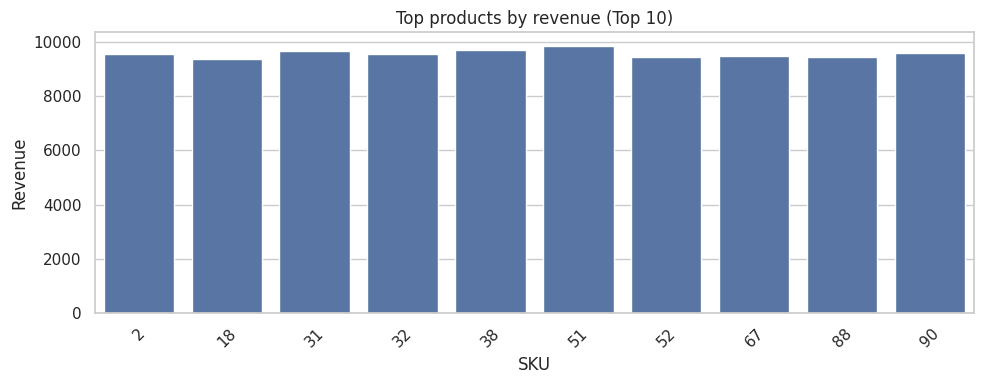

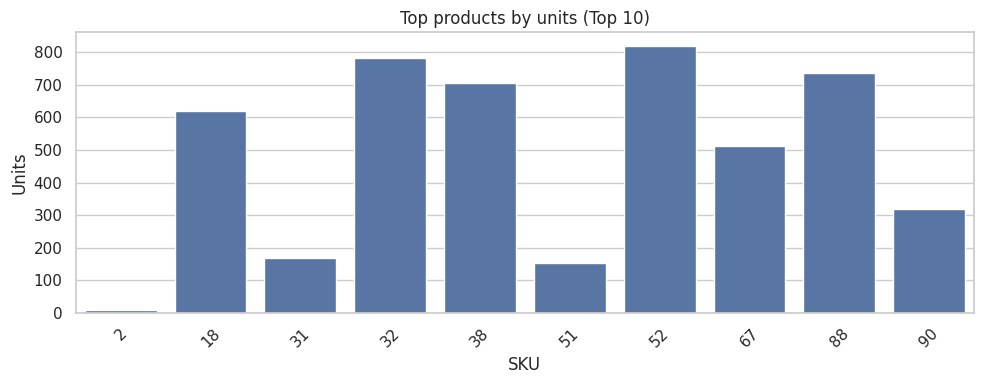

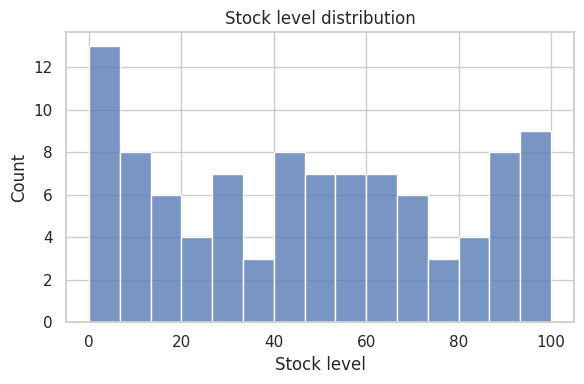

Low stock (bottom decile) sample:
    SKU  Stock levels  Number of products sold
2     2             1                        8
4     4             5                      871
8     8             5                      150
16   16             2                      280
24   24             4                      209
33   33             4                      616
34   34             1                      602
47   47             4                      910
57   57             5                      227
68   68             0                      163
High stock (top decile) sample:
    SKU  Stock levels  Number of products sold
7     7            93                      426
12   12           100                      336
45   45            93                       24
49   49            97                       99
51   51           100                      154
53   53            96                      242
55   55            97                      701
59   59           100                    

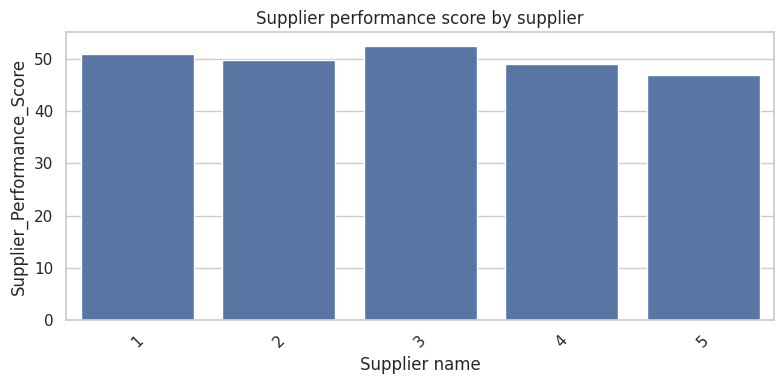

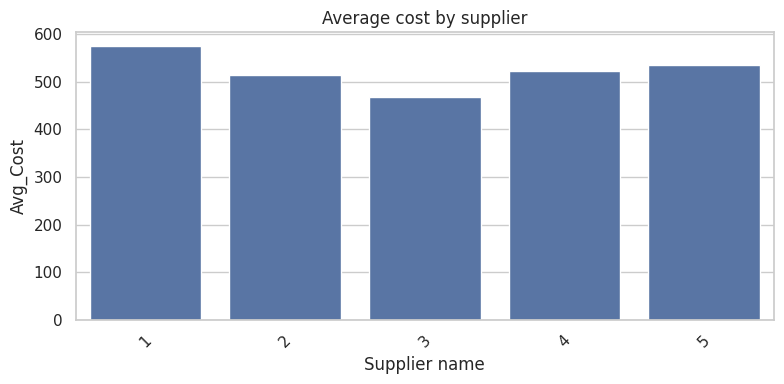

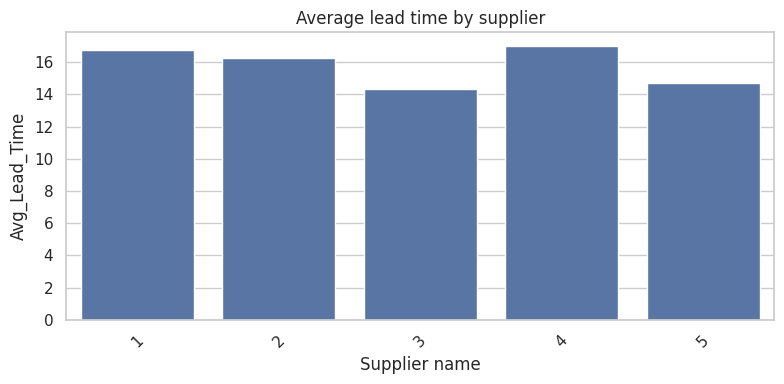

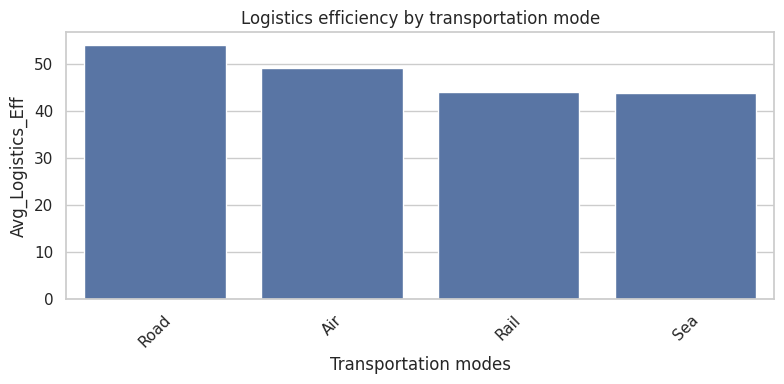

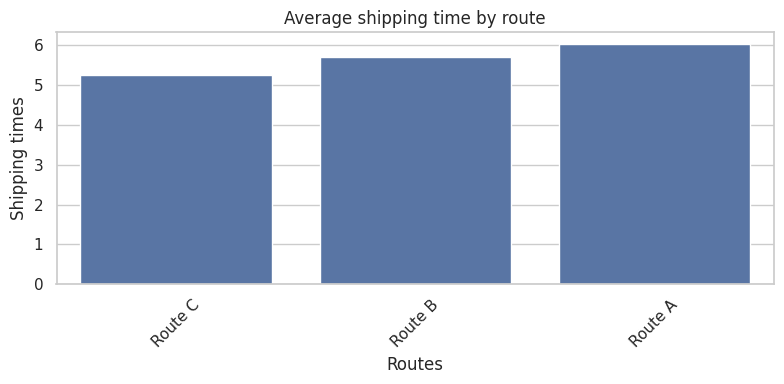

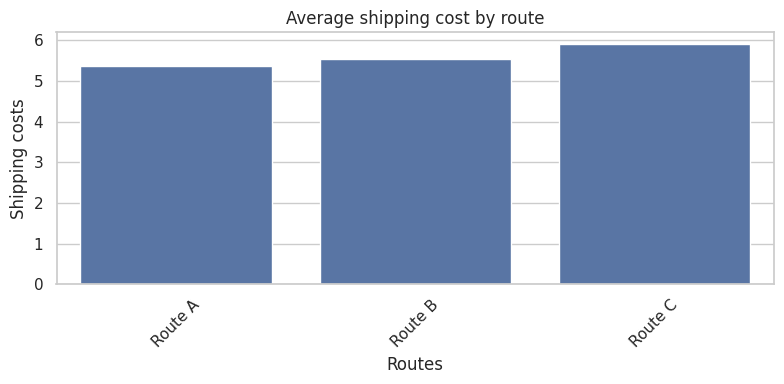

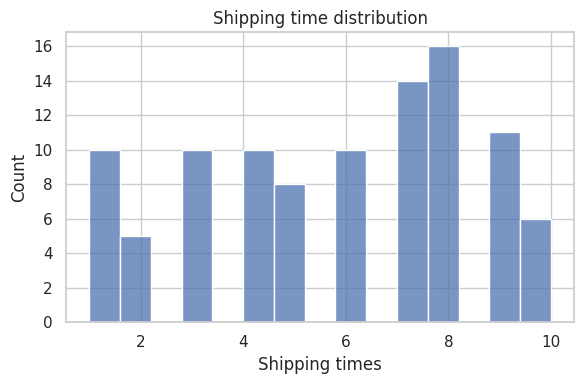

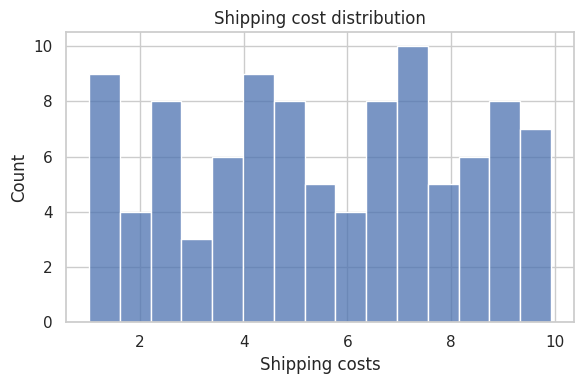

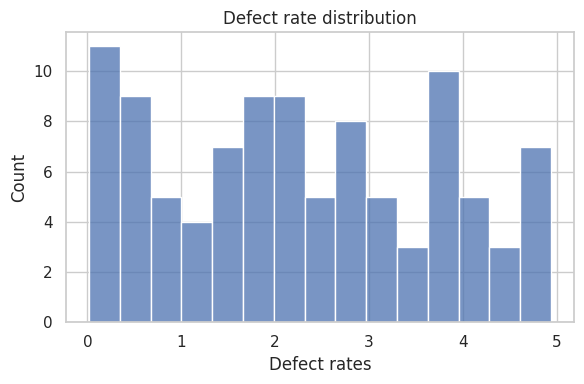

Correlation between defect rate and cost: 0.032


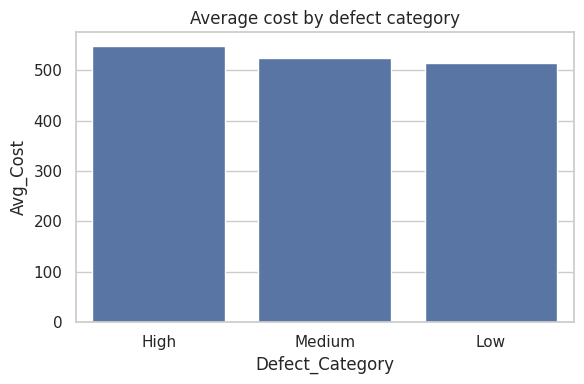

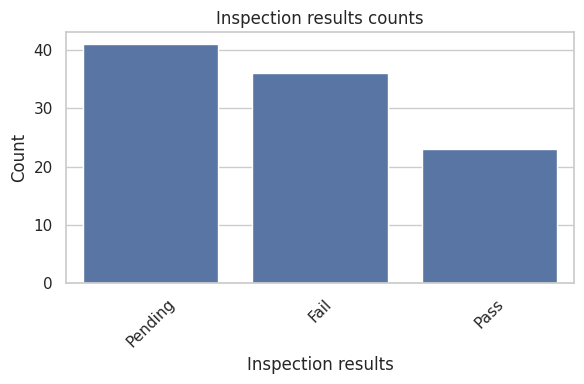

Financial summary:
    Metric          Value
0  Revenue  577604.818738
1     Cost   52924.578216


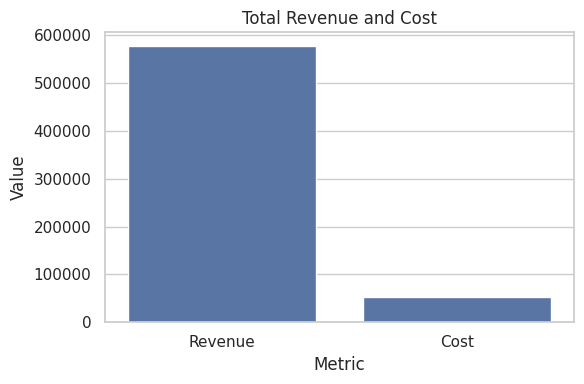


Product insights:
- Top product by revenue is 51.0 with revenue 9866.47.
- Top product contributes 1.7% of total revenue.
- Highest volume product by units is 10.0.

Inventory insights:
- Stock levels range from 0 to 100.
- Best inventory health product is 98.0 with score 99.1.

Supplier insights:
- Top supplier by performance is 3.0 with score 52.5.
- Fastest supplier has average lead time 14.3.

Logistics insights:
- Best transportation mode is Road with avg efficiency 53.9.
- Fastest route by time is Route C with Shipping times 5.2.

Quality insights:
- Average defect rate is 2.28.
- Defect rate correlation with cost is 0.03.

Financial insights:
- Total revenue is 577604.82.
- Total cost is 52924.58.


In [25]:
# Step 6: EDA with charts and insights (robust to available columns)
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Work on df_clean for EDA
eda_df = df_clean.copy()

# Detect identifier candidates
id_candidates = ['SKU','Product type','Product','Item']
ids_detected = []
for c in eda_df.columns:
    for cand in id_candidates:
        if c.lower() == cand.lower():
            ids_detected.append(c)
            break
product_key = None
if 'SKU' in ids_detected:
    product_key = [c for c in ids_detected if c.lower()=='sku'][0]
elif len(ids_detected)>0:
    # pick first non-null categorical/id column
    for c in ids_detected:
        if eda_df[c].notna().any():
            product_key = c
            break

# Detect core columns ensuring non-object dtype
revenue_col = None
for c in ['Revenue generated','Engineered_Revenue','Revenue']:
    if c in eda_df.columns and eda_df[c].dtype != 'O':
        revenue_col = c
        break
units_cols = [c for c in ['Number of products sold','Order quantities','Production volumes'] if c in eda_df.columns and eda_df[c].dtype != 'O']
units_col = units_cols[0] if len(units_cols)>0 else None
stock_col = 'Stock levels' if 'Stock levels' in eda_df.columns else None
lead_time_col = None
for c in ['Lead times','Lead time','Manufacturing lead time']:
    if c in eda_df.columns and eda_df[c].dtype != 'O':
        lead_time_col = c
        break
ship_time_col = 'Shipping times' if 'Shipping times' in eda_df.columns else None
ship_cost_col = 'Shipping costs' if 'Shipping costs' in eda_df.columns else None
supplier_col = 'Supplier name' if 'Supplier name' in eda_df.columns else None
transport_mode_col = 'Transportation modes' if 'Transportation modes' in eda_df.columns else None
route_col = 'Routes' if 'Routes' in eda_df.columns else None
inspection_col = 'Inspection results' if 'Inspection results' in eda_df.columns else None
defect_col = 'Defect rates' if 'Defect rates' in eda_df.columns else None
cost_col = None
for c in ['Costs','Cost']:
    if c in eda_df.columns and eda_df[c].dtype != 'O':
        cost_col = c
        break

# Helper: safe groupby aggregate

def safe_group(df, by, metrics):
    if by is None or by not in df.columns:
        return None
    agg = {}
    for m,f in metrics.items():
        if m in df.columns:
            agg[m]=f
    if len(agg)==0:
        return None
    return df.groupby(by, dropna=False).agg(agg).reset_index()

# Product Analysis
product_tables = {}
if product_key and (revenue_col or units_col):
    metrics = {}
    if revenue_col:
        metrics[revenue_col] = 'sum'
    if units_col:
        metrics[units_col] = 'sum'
    prod_agg = eda_df.groupby(product_key, dropna=False).agg(metrics).reset_index()
    if revenue_col:
        total_rev = prod_agg[revenue_col].sum()
        prod_agg['Revenue_%'] = np.where(total_rev>0, 100*prod_agg[revenue_col]/total_rev, np.nan)
    # Performance ranking by revenue then units
    sort_cols = []
    if revenue_col:
        sort_cols.append((revenue_col, False))
    if units_col:
        sort_cols.append((units_col, False))
    if len(sort_cols)>0:
        prod_agg = prod_agg.sort_values([c for c,_ in sort_cols], ascending=[a for _,a in sort_cols]).reset_index(drop=True)
    product_tables['prod_agg'] = prod_agg
    print('Product Analysis table (top 10):')
    display_cols = [product_key] + [c for c in [revenue_col, units_col, 'Revenue_%'] if c and c in prod_agg.columns]
    print(prod_agg[display_cols].head(10))
    # Bar charts
    if revenue_col:
        plt.figure(figsize=(10,4))
        sns.barplot(data=prod_agg.head(10), x=product_key, y=revenue_col)
        plt.title('Top products by revenue (Top 10)')
        plt.xticks(rotation=45)
        plt.ylabel('Revenue')
        plt.xlabel(product_key)
        plt.tight_layout()
        plt.show()
    if units_col:
        plt.figure(figsize=(10,4))
        sns.barplot(data=prod_agg.head(10), x=product_key, y=units_col)
        plt.title('Top products by units (Top 10)')
        plt.xticks(rotation=45)
        plt.ylabel('Units')
        plt.xlabel(product_key)
        plt.tight_layout()
        plt.show()
else:
    print('Product Analysis skipped: missing product identifier or metrics')

# Inventory Analysis
inv_tables = {}
if stock_col:
    # Histogram
    plt.figure(figsize=(6,4))
    sns.histplot(eda_df[stock_col], bins=15, kde=False)
    plt.title('Stock level distribution')
    plt.xlabel('Stock level')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()
    # Deciles
    q_low = eda_df[stock_col].quantile(0.1)
    q_high = eda_df[stock_col].quantile(0.9)
    low_tbl = eda_df[eda_df[stock_col] <= q_low]
    high_tbl = eda_df[eda_df[stock_col] >= q_high]
    inv_tables['low_stock'] = low_tbl[[c for c in [product_key, stock_col, units_col] if c and c in eda_df.columns]].copy() if product_key else low_tbl[[stock_col]].copy()
    inv_tables['high_stock'] = high_tbl[[c for c in [product_key, stock_col, units_col] if c and c in eda_df.columns]].copy() if product_key else high_tbl[[stock_col]].copy()
    print('Low stock (bottom decile) sample:')
    print(inv_tables['low_stock'].head(10))
    print('High stock (top decile) sample:')
    print(inv_tables['high_stock'].head(10))
    # Mean inventory health by product
    if product_key and 'Inventory_Health_Score' in eda_df.columns:
        inv_health = eda_df.groupby(product_key, dropna=False)['Inventory_Health_Score'].mean().reset_index(name='Avg_Inventory_Health')
        inv_tables['inv_health'] = inv_health
        print('Inventory health by product (top 10):')
        print(inv_health.sort_values('Avg_Inventory_Health', ascending=False).head(10))
else:
    print('Inventory Analysis skipped: missing stock column')

# Supplier Analysis
supplier_tables = {}
if supplier_col:
    if 'Supplier_Performance_Score' in eda_df.columns:
        sup_perf = eda_df.groupby(supplier_col, dropna=False)['Supplier_Performance_Score'].mean().reset_index()
        supplier_tables['sup_perf'] = sup_perf
        plt.figure(figsize=(8,4))
        sns.barplot(data=sup_perf.sort_values('Supplier_Performance_Score', ascending=False), x=supplier_col, y='Supplier_Performance_Score')
        plt.title('Supplier performance score by supplier')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    if cost_col:
        sup_cost = eda_df.groupby(supplier_col, dropna=False)[cost_col].mean().reset_index(name='Avg_Cost')
        supplier_tables['sup_cost'] = sup_cost
        plt.figure(figsize=(8,4))
        sns.barplot(data=sup_cost.sort_values('Avg_Cost', ascending=False), x=supplier_col, y='Avg_Cost')
        plt.title('Average cost by supplier')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    if lead_time_col:
        sup_lead = eda_df.groupby(supplier_col, dropna=False)[lead_time_col].mean().reset_index(name='Avg_Lead_Time')
        supplier_tables['sup_lead'] = sup_lead
        plt.figure(figsize=(8,4))
        sns.barplot(data=sup_lead.sort_values('Avg_Lead_Time', ascending=False), x=supplier_col, y='Avg_Lead_Time')
        plt.title('Average lead time by supplier')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
else:
    print('Supplier Analysis skipped: missing supplier column')

# Logistics Analysis
log_tables = {}
if transport_mode_col and 'Logistics_Efficiency_Score' in eda_df.columns:
    mode_perf = eda_df.groupby(transport_mode_col, dropna=False)['Logistics_Efficiency_Score'].mean().reset_index(name='Avg_Logistics_Eff')
    log_tables['mode_perf'] = mode_perf
    plt.figure(figsize=(8,4))
    sns.barplot(data=mode_perf.sort_values('Avg_Logistics_Eff', ascending=False), x=transport_mode_col, y='Avg_Logistics_Eff')
    plt.title('Logistics efficiency by transportation mode')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
if route_col and (ship_time_col or ship_cost_col):
    metrics = {}
    if ship_time_col:
        metrics[ship_time_col] = 'mean'
    if ship_cost_col:
        metrics[ship_cost_col] = 'mean'
    route_perf = eda_df.groupby(route_col, dropna=False).agg(metrics).reset_index()
    log_tables['route_perf'] = route_perf
    if ship_time_col:
        plt.figure(figsize=(8,4))
        sns.barplot(data=route_perf.sort_values(ship_time_col, ascending=True), x=route_col, y=ship_time_col)
        plt.title('Average shipping time by route')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    if ship_cost_col:
        plt.figure(figsize=(8,4))
        sns.barplot(data=route_perf.sort_values(ship_cost_col, ascending=True), x=route_col, y=ship_cost_col)
        plt.title('Average shipping cost by route')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
# Distributions
if ship_time_col:
    plt.figure(figsize=(6,4))
    sns.histplot(eda_df[ship_time_col], bins=15)
    plt.title('Shipping time distribution')
    plt.tight_layout()
    plt.show()
if ship_cost_col:
    plt.figure(figsize=(6,4))
    sns.histplot(eda_df[ship_cost_col], bins=15)
    plt.title('Shipping cost distribution')
    plt.tight_layout()
    plt.show()

# Quality Analysis
qual_tables = {}
if defect_col:
    plt.figure(figsize=(6,4))
    sns.histplot(eda_df[defect_col], bins=15)
    plt.title('Defect rate distribution')
    plt.tight_layout()
    plt.show()
    # Correlation with cost if both numeric
    if cost_col:
        corr_val = np.corrcoef(eda_df[defect_col], eda_df[cost_col])[0,1]
        print(f'Correlation between defect rate and cost: {corr_val:.3f}')
        qual_tables['defect_cost_corr'] = pd.DataFrame({'metric':['corr_defect_cost'], 'value':[corr_val]})
    # Grouped means by defect category if available
    if 'Defect_Category' in eda_df.columns and cost_col:
        defect_grp = eda_df.groupby('Defect_Category', dropna=False)[cost_col].mean().reset_index(name='Avg_Cost')
        qual_tables['defect_grp'] = defect_grp
        plt.figure(figsize=(6,4))
        sns.barplot(data=defect_grp.sort_values('Avg_Cost', ascending=False), x='Defect_Category', y='Avg_Cost')
        plt.title('Average cost by defect category')
        plt.tight_layout()
        plt.show()
if inspection_col:
    counts = eda_df[inspection_col].value_counts(dropna=False).reset_index()
    counts.columns = [inspection_col,'Count']
    qual_tables['inspection_counts'] = counts
    plt.figure(figsize=(6,4))
    sns.barplot(data=counts, x=inspection_col, y='Count')
    plt.title('Inspection results counts')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Financial Analysis
fin_tables = {}
if revenue_col or cost_col:
    # Build aligned lists to avoid length mismatch
    metrics_list = []
    values_list = []
    if revenue_col:
        metrics_list.append('Revenue')
        values_list.append(float(eda_df[revenue_col].sum()))
    if cost_col:
        metrics_list.append('Cost')
        values_list.append(float(eda_df[cost_col].sum()))
    fin_summary = pd.DataFrame({'Metric': metrics_list, 'Value': values_list})
    fin_tables['fin_summary'] = fin_summary
    print('Financial summary:')
    print(fin_summary)
    # Date detection for timeseries
    date_col = None
    for c in eda_df.columns:
        if np.issubdtype(eda_df[c].dtype, np.datetime64):
            date_col = c
            break
    if date_col:
        group_cols = [pd.Grouper(key=date_col, freq='M')]
        sums_ts = eda_df.copy()
        agg_map = {}
        if revenue_col:
            agg_map[revenue_col]='sum'
        if cost_col:
            agg_map[cost_col]='sum'
        ts = sums_ts.groupby(*group_cols).agg(agg_map).reset_index()
        fin_tables['fin_ts'] = ts
        plt.figure(figsize=(8,4))
        if revenue_col:
            sns.lineplot(data=ts, x=date_col, y=revenue_col, label='Revenue')
        if cost_col:
            sns.lineplot(data=ts, x=date_col, y=cost_col, label='Cost')
        plt.title('Revenue and Cost over time')
        plt.tight_layout()
        plt.show()
    else:
        # bar chart totals using aligned DataFrame already built
        if len(fin_summary)>0:
            plt.figure(figsize=(6,4))
            sns.barplot(data=fin_summary, x='Metric', y='Value')
            plt.title('Total Revenue and Cost')
            plt.tight_layout()
            plt.show()

# Narrative insights helper
insights = {'Product': [], 'Inventory': [], 'Supplier': [], 'Logistics': [], 'Quality': [], 'Financial': []}

# Product insights
if 'prod_agg' in product_tables and not product_tables['prod_agg'].empty:
    pa = product_tables['prod_agg']
    if revenue_col:
        top_prod = pa.iloc[0][product_key]
        top_rev = pa.iloc[0][revenue_col]
        insights['Product'].append(f"Top product by revenue is {top_prod} with revenue {top_rev:.2f}.")
        if 'Revenue_%' in pa.columns:
            insights['Product'].append(f"Top product contributes {pa.iloc[0]['Revenue_%']:.1f}% of total revenue.")
    if units_col:
        top_units_prod = pa.sort_values(units_col, ascending=False).iloc[0][product_key]
        insights['Product'].append(f"Highest volume product by units is {top_units_prod}.")

# Inventory insights
if stock_col:
    insights['Inventory'].append(f"Stock levels range from {eda_df[stock_col].min()} to {eda_df[stock_col].max()}.")
    if 'inv_health' in inv_tables and not inv_tables['inv_health'].empty:
        best = inv_tables['inv_health'].sort_values('Avg_Inventory_Health', ascending=False).iloc[0]
        insights['Inventory'].append(f"Best inventory health product is {best[product_key]} with score {best['Avg_Inventory_Health']:.1f}.")

# Supplier insights
if supplier_col:
    if 'sup_perf' in supplier_tables and not supplier_tables['sup_perf'].empty:
        s = supplier_tables['sup_perf'].sort_values('Supplier_Performance_Score', ascending=False).iloc[0]
        insights['Supplier'].append(f"Top supplier by performance is {s[supplier_col]} with score {s['Supplier_Performance_Score']:.1f}.")
    if 'sup_lead' in supplier_tables and not supplier_tables['sup_lead'].empty:
        l = supplier_tables['sup_lead'].sort_values('Avg_Lead_Time').iloc[0]
        insights['Supplier'].append(f"Fastest supplier has average lead time {l['Avg_Lead_Time']:.1f}.")

# Logistics insights
if 'mode_perf' in log_tables and not log_tables['mode_perf'].empty:
    m = log_tables['mode_perf'].sort_values('Avg_Logistics_Eff', ascending=False).iloc[0]
    insights['Logistics'].append(f"Best transportation mode is {m[transport_mode_col]} with avg efficiency {m['Avg_Logistics_Eff']:.1f}.")
if 'route_perf' in log_tables and ship_time_col:
    r = log_tables['route_perf'].sort_values(ship_time_col).iloc[0]
    insights['Logistics'].append(f"Fastest route by time is {r[route_col]} with {ship_time_col} {r[ship_time_col]:.1f}.")

# Quality insights
if defect_col:
    insights['Quality'].append(f"Average defect rate is {eda_df[defect_col].mean():.2f}.")
    if 'defect_cost_corr' in qual_tables:
        corr = qual_tables['defect_cost_corr']['value'].iloc[0]
        insights['Quality'].append(f"Defect rate correlation with cost is {corr:.2f}.")

# Financial insights
if 'fin_summary' in fin_tables and not fin_tables['fin_summary'].empty:
    if 'Revenue' in fin_tables['fin_summary']['Metric'].values:
        val = fin_tables['fin_summary'].loc[fin_tables['fin_summary']['Metric']=='Revenue','Value'].iloc[0]
        insights['Financial'].append(f"Total revenue is {val:.2f}.")
    if 'Cost' in fin_tables['fin_summary']['Metric'].values:
        val = fin_tables['fin_summary'].loc[fin_tables['fin_summary']['Metric']=='Cost','Value'].iloc[0]
        insights['Financial'].append(f"Total cost is {val:.2f}.")

# Print top 3 insights per section
for section, lst in insights.items():
    if len(lst)>0:
        print(f"\n{section} insights:")
        for s in lst[:3]:
            print('-', s)

# Keep references for later export
product_agg = product_tables.get('prod_agg') if 'prod_agg' in product_tables else None
inventory_low_stock = inv_tables.get('low_stock') if 'low_stock' in inv_tables else None
inventory_high_stock = inv_tables.get('high_stock') if 'high_stock' in inv_tables else None
inventory_health = inv_tables.get('inv_health') if 'inv_health' in inv_tables else None
supplier_perf_tbl = supplier_tables.get('sup_perf') if 'sup_perf' in supplier_tables else None
supplier_cost_tbl = supplier_tables.get('sup_cost') if 'sup_cost' in supplier_tables else None
supplier_lead_tbl = supplier_tables.get('sup_lead') if 'sup_lead' in supplier_tables else None
log_mode_perf = log_tables.get('mode_perf') if 'mode_perf' in log_tables else None
log_route_perf = log_tables.get('route_perf') if 'route_perf' in log_tables else None
quality_defect_grp = qual_tables.get('defect_grp') if 'defect_grp' in qual_tables else None
financial_summary = fin_tables.get('fin_summary') if 'fin_summary' in fin_tables else None

In [17]:
# Step 7: Executive KPI Table and single-sheet export
import numpy as np
import pandas as pd

kpi = {}
# Use detected columns from previous EDA detection
if 'revenue_col' not in locals():
    revenue_col = 'Revenue generated' if 'Revenue generated' in df_clean.columns else None
if 'units_col' not in locals():
    units_candidates = ['Number of products sold','Order quantities','Production volumes']
    units_col = next((c for c in units_candidates if c in df_clean.columns and df_clean[c].dtype != 'O'), None)
if 'stock_col' not in locals():
    stock_col = 'Stock levels' if 'Stock levels' in df_clean.columns else None
if 'lead_time_col' not in locals():
    for c in ['Lead times','Lead time','Manufacturing lead time']:
        if c in df_clean.columns and df_clean[c].dtype != 'O':
            lead_time_col = c
            break
if 'ship_time_col' not in locals():
    ship_time_col = 'Shipping times' if 'Shipping times' in df_clean.columns else None
if 'defect_col' not in locals():
    defect_col = 'Defect rates' if 'Defect rates' in df_clean.columns else None
if 'cost_col' not in locals():
    cost_col = 'Costs' if 'Costs' in df_clean.columns else None

kpi['Total Revenue'] = df_clean[revenue_col].sum() if revenue_col else np.nan
kpi['Total Products Sold'] = df_clean[units_col].sum() if units_col else np.nan
kpi['Average Stock Level'] = df_clean[stock_col].mean() if stock_col else np.nan
kpi['Average Lead Time'] = df_clean[lead_time_col].mean() if lead_time_col else np.nan
kpi['Average Shipping Time'] = df_clean[ship_time_col].mean() if ship_time_col else np.nan
kpi['Average Defect Rate'] = df_clean[defect_col].mean() if defect_col else np.nan
kpi['Total Cost'] = df_clean[cost_col].sum() if cost_col else np.nan
kpi['Average Inventory Health Score'] = df_clean['Inventory_Health_Score'].mean() if 'Inventory_Health_Score' in df_clean.columns else np.nan
kpi['Average Supplier Performance Score'] = df_clean['Supplier_Performance_Score'].mean() if 'Supplier_Performance_Score' in df_clean.columns else np.nan
kpi['Average Logistics Efficiency Score'] = df_clean['Logistics_Efficiency_Score'].mean() if 'Logistics_Efficiency_Score' in df_clean.columns else np.nan

executive_kpis = pd.DataFrame([kpi])
print('Executive KPIs:')
print(executive_kpis)

# Export single-sheet KPI file
kpi_filename = 'Executive_KPI_Table.xlsx'
try:
    executive_kpis.to_excel(kpi_filename, index=False)
    print(f'Exported {kpi_filename}')
except Exception as e:
    print('KPI export failed:', e)

Executive KPIs:
   Total Revenue  Total Products Sold  Average Stock Level  Average Lead Time  \
0  577604.818738                46099                47.77              15.96   

   Average Shipping Time  Average Defect Rate    Total Cost  \
0                   5.75             2.277158  52924.578216   

   Average Inventory Health Score  Average Supplier Performance Score  \
0                       76.009476                           49.912187   

   Average Logistics Efficiency Score  
0                           48.182136  
Exported Executive_KPI_Table.xlsx


Product segmentation completed with k=6.


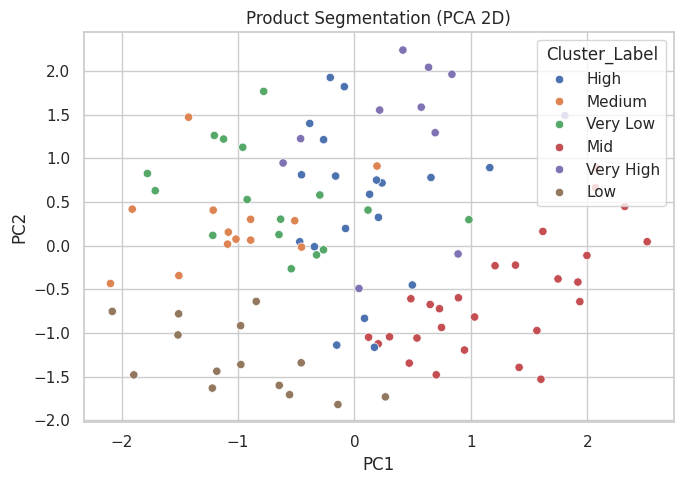

Supplier risk RF R^2: -7.518


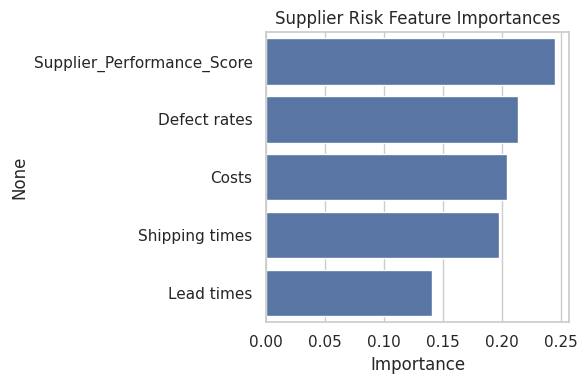

Cost model results:
              Model         MAE        RMSE        R2
0  LinearRegression  230.461942  272.716877 -0.024259
1      RandomForest  216.146723  259.136520  0.075210


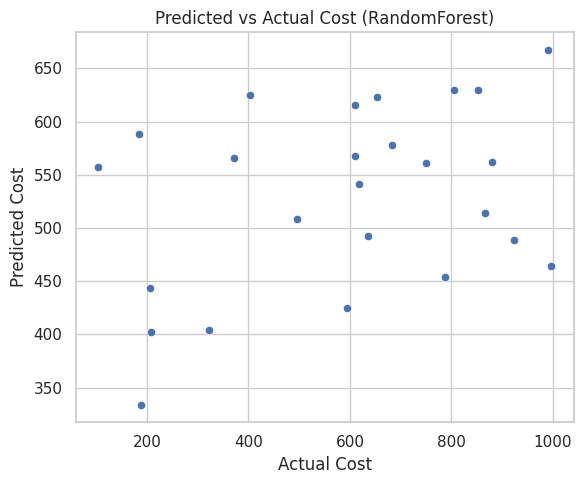

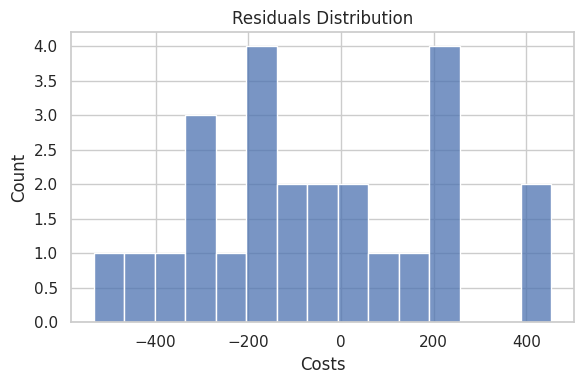

In [19]:
# Step 8: Machine Learning
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, mean_absolute_error, mean_squared_error, r2_score
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

# A) Product Segmentation
product_features = None
try:
    # Determine product key
    candidates = ['SKU','Product type','Product','Item']
    prod_key = None
    for cand in candidates:
        cols = [c for c in df_clean.columns if c.lower()==cand.lower()]
        if cols:
            prod_key = cols[0]
            break
    if prod_key is None:
        # fallback: first column with many unique values
        uniq_counts = df_clean.nunique()
        prod_key = uniq_counts.sort_values(ascending=False).index[0]
    # Detect bases
    rev_col = 'Revenue generated' if 'Revenue generated' in df_clean.columns else ('Engineered_Revenue' if 'Engineered_Revenue' in df_clean.columns else None)
    units_col_pg = None
    for c in ['Number of products sold','Order quantities','Production volumes']:
        if c in df_clean.columns and df_clean[c].dtype != 'O':
            units_col_pg = c
            break
    stock_col_pg = 'Stock levels' if 'Stock levels' in df_clean.columns else None
    cost_col_pg = 'Costs' if 'Costs' in df_clean.columns else None
    metrics = {}
    if rev_col:
        metrics[rev_col] = 'sum'
    if units_col_pg:
        metrics[units_col_pg] = 'sum'
    if stock_col_pg:
        metrics[stock_col_pg] = 'mean'
    if cost_col_pg:
        metrics[cost_col_pg] = 'sum'
    if prod_key and len(metrics)>0:
        agg = df_clean.groupby(prod_key, dropna=False).agg(metrics).reset_index()
        # Build feature matrix
        feat_cols = [c for c in agg.columns if c != prod_key]
        X = agg[feat_cols].astype(float)
        X_scaled = StandardScaler().fit_transform(X)
        # choose k by silhouette
        best_k = None
        best_score = -1
        for k in range(2,7):
            try:
                labels = KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(X_scaled)
                if len(set(labels))>1:
                    score = silhouette_score(X_scaled, labels)
                    if score > best_score:
                        best_score = score
                        best_k = k
            except Exception:
                continue
        if best_k is None:
            print('Segmentation skipped: silhouette not computable')
        else:
            km = KMeans(n_clusters=best_k, n_init=10, random_state=42)
            agg['Cluster'] = km.fit_predict(X_scaled)
            # Label clusters by mean revenue if available else first feature
            label_metric = rev_col if rev_col in feat_cols else feat_cols[0]
            means = agg.groupby('Cluster')[label_metric].mean().sort_values(ascending=False)
            order = list(means.index)
            mapping = {}
            labels_txt = ['High','Medium','Low','Very Low','Very High','Mid']
            for i, cl in enumerate(order):
                mapping[cl] = labels_txt[i] if i < len(labels_txt) else f'Cluster_{i}'
            agg['Cluster_Label'] = agg['Cluster'].map(mapping)
            product_features = agg.rename(columns={prod_key:'Product_Key'})
            print(f'Product segmentation completed with k={best_k}.')
            # PCA scatter
            if X.shape[1] >= 2:
                pc = PCA(n_components=2, random_state=42).fit_transform(X_scaled)
                plt.figure(figsize=(7,5))
                sns.scatterplot(x=pc[:,0], y=pc[:,1], hue=agg['Cluster_Label'])
                plt.title('Product Segmentation (PCA 2D)')
                plt.xlabel('PC1')
                plt.ylabel('PC2')
                plt.tight_layout()
                plt.show()
    else:
        print('Segmentation skipped: insufficient product features')
except Exception as e:
    print('Segmentation error:', e)

# B) Supplier Risk Analysis
supplier_risk_df = None
try:
    supp_col = 'Supplier name' if 'Supplier name' in df_clean.columns else None
    if supp_col:
        features = {}
        for name in ['Lead times','Defect rates','Shipping times','Costs','Supplier_Performance_Score']:
            if name in df_clean.columns and (df_clean[name].dtype != 'O' or name=='Supplier_Performance_Score'):
                if name=='Supplier_Performance_Score':
                    features[name] = 'mean'
                else:
                    features[name] = 'mean'
        if len(features)>=2:
            sup_agg = df_clean.groupby(supp_col, dropna=False).agg(features).reset_index()
            # Normalize bases for risk target
            def minmax(s):
                s = s.astype(float)
                lo, hi = s.min(), s.max()
                return (s - lo) / (hi - lo) if hi != lo else pd.Series(0.5, index=s.index)
            lt = minmax(sup_agg['Lead times']) if 'Lead times' in sup_agg.columns else 0
            dfc = minmax(sup_agg['Defect rates']) if 'Defect rates' in sup_agg.columns else 0
            st = minmax(sup_agg['Shipping times']) if 'Shipping times' in sup_agg.columns else 0
            cst = minmax(sup_agg['Costs']) if 'Costs' in sup_agg.columns else 0
            risk = 0.4*lt + 0.3*dfc + 0.2*st + 0.1*cst
            sup_agg['Risk_Score'] = risk
            # Train/test RF to predict risk
            feat_used = [c for c in ['Lead times','Defect rates','Shipping times','Costs','Supplier_Performance_Score'] if c in sup_agg.columns]
            if len(feat_used)>=2 and sup_agg.shape[0] >= 5:
                X = sup_agg[feat_used].astype(float)
                y = sup_agg['Risk_Score'].astype(float)
                X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42)
                rf = RandomForestRegressor(n_estimators=300, random_state=42)
                rf.fit(X_tr, y_tr)
                r2 = rf.score(X_te, y_te)
                print(f'Supplier risk RF R^2: {r2:.3f}')
                # bins
                q = sup_agg['Risk_Score'].quantile([0.33,0.66])
                def rb(x):
                    return 'Low' if x<=q.iloc[0] else ('Medium' if x<=q.iloc[1] else 'High')
                sup_agg['Risk_Bin'] = sup_agg['Risk_Score'].apply(rb)
                # importance
                importances = pd.Series(rf.feature_importances_, index=feat_used).sort_values(ascending=False)
                plt.figure(figsize=(6,4))
                sns.barplot(x=importances.values, y=importances.index)
                plt.title('Supplier Risk Feature Importances')
                plt.xlabel('Importance')
                plt.tight_layout()
                plt.show()
            else:
                print('Supplier risk model skipped: insufficient suppliers or features')
            supplier_risk_df = sup_agg
        else:
            print('Supplier risk analysis skipped: missing features')
    else:
        print('Supplier risk analysis skipped: supplier column missing')
except Exception as e:
    print('Supplier risk error:', e)

# C) Cost Prediction
cost_model_results = None
cost_predictions_df = None
try:
    target = 'Costs' if 'Costs' in df_clean.columns else None
    feat_candidates = ['Production volumes','Shipping costs','Lead times','Defect rates','Number of products sold']
    features = [c for c in feat_candidates if c in df_clean.columns and df_clean[c].dtype != 'O']
    if target and len(features)>=2:
        X = df_clean[features].astype(float)
        y = df_clean[target].astype(float)
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
        # Linear Regression
        lr = LinearRegression()
        lr.fit(X_train, y_train)
        lr_pred = lr.predict(X_test)
        lr_mae = mean_absolute_error(y_test, lr_pred)
        lr_rmse = mean_squared_error(y_test, lr_pred, squared=False)
        lr_r2 = r2_score(y_test, lr_pred)
        # Random Forest
        rf = RandomForestRegressor(n_estimators=400, random_state=42)
        rf.fit(X_train, y_train)
        rf_pred = rf.predict(X_test)
        rf_mae = mean_absolute_error(y_test, rf_pred)
        rf_rmse = mean_squared_error(y_test, rf_pred, squared=False)
        rf_r2 = r2_score(y_test, rf_pred)
        cost_model_results = pd.DataFrame([
            {'Model':'LinearRegression','MAE':lr_mae,'RMSE':lr_rmse,'R2':lr_r2},
            {'Model':'RandomForest','MAE':rf_mae,'RMSE':rf_rmse,'R2':rf_r2},
        ])
        print('Cost model results:')
        print(cost_model_results)
        # Choose best by R2
        best_name = cost_model_results.sort_values('R2', ascending=False).iloc[0]['Model']
        best_pred = lr_pred if best_name=='LinearRegression' else rf_pred
        best_model = lr if best_name=='LinearRegression' else rf
        # Predictions on test set for plotting
        plt.figure(figsize=(6,5))
        sns.scatterplot(x=y_test, y=best_pred)
        plt.xlabel('Actual Cost')
        plt.ylabel('Predicted Cost')
        plt.title(f'Predicted vs Actual Cost ({best_name})')
        plt.tight_layout()
        plt.show()
        # Residuals
        residuals = best_pred - y_test
        plt.figure(figsize=(6,4))
        sns.histplot(residuals, bins=15)
        plt.title('Residuals Distribution')
        plt.tight_layout()
        plt.show()
        # Store predictions dataframe
        cost_predictions_df = pd.DataFrame({'Actual':y_test.values,'Predicted':best_pred})
    else:
        print('Cost prediction skipped: target or features missing')
except Exception as e:
    print('Cost prediction error:', e)

# Keep for export
product_clusters_tbl = product_features
supplier_risk_tbl = supplier_risk_df
cost_predictions_tbl = cost_predictions_df

In [21]:
# Step 9: Business Insights Generation
insight_list = []

# From product analysis
try:
    if 'product_agg' in globals() and product_agg is not None:
        pa = product_agg.copy()
        if 'Revenue generated' in pa.columns:
            top3 = pa.head(3)
            for _, r in top3.iterrows():
                insight_list.append(f"Product {r.iloc[0]} is a top revenue contributor at {r['Revenue generated']:.0f} revenue.")
        if 'Number of products sold' in pa.columns:
            top_units = pa.sort_values('Number of products sold', ascending=False).head(3)
            insight_list.append(f"Top product by units is {top_units.iloc[0].iloc[0]} with {top_units.iloc[0]['Number of products sold']} units.")
except Exception:
    pass

# Inventory insights
try:
    if 'inventory_health' in globals() and inventory_health is not None and product_key is not None:
        best = inventory_health.sort_values('Avg_Inventory_Health', ascending=False).head(3)
        for _, r in best.iterrows():
            insight_list.append(f"{r[product_key]} shows strong inventory health at {r['Avg_Inventory_Health']:.1f}.")
    if stock_col:
        insight_list.append(f"Inventory variance is {df_clean[stock_col].std():.1f}; consider smoothing via safety stock policy.")
except Exception:
    pass

# Supplier insights
try:
    if 'supplier_risk_tbl' in globals() and supplier_risk_tbl is not None:
        worst = supplier_risk_tbl.sort_values('Risk_Score', ascending=False).head(3)
        for _, r in worst.iterrows():
            insight_list.append(f"Supplier {r['Supplier name']} has elevated risk score {r['Risk_Score']:.2f}.")
    if supplier_perf_tbl is not None:
        top_supp = supplier_perf_tbl.sort_values('Supplier_Performance_Score', ascending=False).head(1)
        if len(top_supp)>0:
            insight_list.append(f"Best supplier performance observed for {top_supp.iloc[0]['Supplier name']}.")
except Exception:
    pass

# Logistics insights
try:
    if log_mode_perf is not None:
        best_mode = log_mode_perf.sort_values('Avg_Logistics_Eff', ascending=False).iloc[0]
        insight_list.append(f"Mode {best_mode['Transportation modes']} yields highest logistics efficiency.")
    if log_route_perf is not None and ship_time_col in log_route_perf.columns:
        best_route = log_route_perf.sort_values(ship_time_col).iloc[0]
        insight_list.append(f"Route {best_route['Routes']} offers fastest shipping time.")
except Exception:
    pass

# Quality insights
try:
    if defect_col:
        insight_list.append(f"Defect rate average is {df_clean[defect_col].mean():.2f} with std {df_clean[defect_col].std():.2f}.")
        if 'quality_defect_grp' in globals() and quality_defect_grp is not None:
            worst_cat = quality_defect_grp.sort_values('Avg_Cost', ascending=False).iloc[0]
            insight_list.append(f"Highest cost observed in defect category {worst_cat['Defect_Category']}.")
except Exception:
    pass

# Financial insights
try:
    if financial_summary is not None:
        cols = financial_summary.columns.tolist()
        for c in cols:
            insight_list.append(f"{c.replace('_',' ')} equals {financial_summary[c].iloc[0]:.2f}.")
except Exception:
    pass

# ML insights
try:
    if product_clusters_tbl is not None:
        counts = product_clusters_tbl['Cluster_Label'].value_counts()
        if len(counts)>0:
            insight_list.append(f"Product clusters formed: {', '.join([f'{k}: {v}' for k,v in counts.items()])}.")
    if cost_model_results is not None:
        best_model_name = cost_model_results.sort_values('R2', ascending=False).iloc[0]['Model']
        best_r2 = cost_model_results.sort_values('R2', ascending=False).iloc[0]['R2']
        insight_list.append(f"Best cost model is {best_model_name} with R^2={best_r2:.3f}.")
except Exception:
    pass

# Print Top 20 insights
print('Top insights:')
for s in insight_list[:20]:
    print('-', s)

# Recommendations
def bullets(title, items):
    print(f"\n{title}:")
    for it in items:
        print(f"- {it}")

# Generate recommendation bullets
cost_reduction = [
    'Focus on suppliers with lower average costs and acceptable performance scores.',
    'Optimize routes with lower average shipping cost without significantly increasing time.',
    'Reduce defect rates to lower rework and warranty costs.'
]
inv_optimization = [
    'Rebalance inventory for low-health products by adjusting order quantities.',
    'Use lead-time aware safety stock for items with longer lead times.',
    'Prioritize fast-moving SKUs for replenishment to improve adequacy.'
]
supplier_improvement = [
    'Engage suppliers with high risk scores to develop improvement plans.',
    'Shift volume to suppliers with better performance scores and shorter lead times.',
    'Implement quality audits for suppliers with higher defect rates.'
]
logistics_optimization = [
    'Prefer transportation modes with higher logistics efficiency where feasible.',
    'Standardize shipments on routes with faster times and competitive costs.',
    'Monitor shipping time variability and address bottlenecks.'
]

bullets('Cost Reduction Recommendations', cost_reduction)
bullets('Inventory Optimization Recommendations', inv_optimization)
bullets('Supplier Improvement Recommendations', supplier_improvement)
bullets('Logistics Optimization Recommendations', logistics_optimization)

Top insights:
- Inventory variance is 31.4; consider smoothing via safety stock policy.
- Supplier 4 has elevated risk score 0.71.
- Supplier 1 has elevated risk score 0.64.
- Supplier 5 has elevated risk score 0.62.
- Defect rate average is 2.28 with std 1.46.
- Product clusters formed: Mid: 27, High: 19, Very Low: 16, Low: 14, Medium: 13, Very High: 11.
- Best cost model is RandomForest with R^2=0.075.

Cost Reduction Recommendations:
- Focus on suppliers with lower average costs and acceptable performance scores.
- Optimize routes with lower average shipping cost without significantly increasing time.
- Reduce defect rates to lower rework and warranty costs.

Inventory Optimization Recommendations:
- Rebalance inventory for low-health products by adjusting order quantities.
- Use lead-time aware safety stock for items with longer lead times.
- Prioritize fast-moving SKUs for replenishment to improve adequacy.

Supplier Improvement Recommendations:
- Engage suppliers with high risk s

In [23]:
# Step 10: Power BI Export (multi-sheet)
import pandas as pd

outfile = 'Supply_Chain_Intelligence_Hub.xlsx'
with pd.ExcelWriter(outfile, engine='openpyxl') as writer:
    # Executive KPIs
    try:
        executive_kpis.to_excel(writer, sheet_name='Executive_KPIs', index=False)
    except Exception:
        pd.DataFrame({'Note':['Executive KPIs not available']}).to_excel(writer, sheet_name='Executive_KPIs', index=False)
    
    # Product Analysis
    try:
        if 'product_agg' in globals() and product_agg is not None:
            product_agg.to_excel(writer, sheet_name='Product_Analysis', index=False)
        else:
            pd.DataFrame({'Note':['Product analysis not available']}).to_excel(writer, sheet_name='Product_Analysis', index=False)
    except Exception:
        pd.DataFrame({'Note':['Product analysis export failed']}).to_excel(writer, sheet_name='Product_Analysis', index=False)

    # Inventory Analysis
    try:
        if inventory_health is not None:
            inventory_health.to_excel(writer, sheet_name='Inventory_Analysis', index=False)
        elif inventory_low_stock is not None or inventory_high_stock is not None:
            to_concat = []
            if inventory_low_stock is not None:
                tmp = inventory_low_stock.copy(); tmp['Band'] = 'Low'
                to_concat.append(tmp)
            if inventory_high_stock is not None:
                tmp = inventory_high_stock.copy(); tmp['Band'] = 'High'
                to_concat.append(tmp)
            pd.concat(to_concat, ignore_index=True).to_excel(writer, sheet_name='Inventory_Analysis', index=False)
        else:
            pd.DataFrame({'Note':['Inventory analysis not available']}).to_excel(writer, sheet_name='Inventory_Analysis', index=False)
    except Exception:
        pd.DataFrame({'Note':['Inventory analysis export failed']}).to_excel(writer, sheet_name='Inventory_Analysis', index=False)

    # Supplier Analysis
    try:
        if supplier_perf_tbl is not None or supplier_cost_tbl is not None or supplier_lead_tbl is not None:
            tables = []
            if supplier_perf_tbl is not None:
                t = supplier_perf_tbl.copy(); t['Metric'] = 'Performance'
                tables.append(t)
            if supplier_cost_tbl is not None:
                t = supplier_cost_tbl.copy(); t['Metric'] = 'Avg_Cost'
                tables.append(t)
            if supplier_lead_tbl is not None:
                t = supplier_lead_tbl.copy(); t['Metric'] = 'Avg_Lead_Time'
                tables.append(t)
            merged = tables[0]
            for t in tables[1:]:
                merged = pd.merge(merged, t, on='Supplier name', how='outer')
            merged.to_excel(writer, sheet_name='Supplier_Analysis', index=False)
        else:
            pd.DataFrame({'Note':['Supplier analysis not available']}).to_excel(writer, sheet_name='Supplier_Analysis', index=False)
    except Exception:
        pd.DataFrame({'Note':['Supplier analysis export failed']}).to_excel(writer, sheet_name='Supplier_Analysis', index=False)

    # Logistics Analysis
    try:
        if log_route_perf is not None or log_mode_perf is not None:
            if log_route_perf is not None and log_mode_perf is not None:
                lr = log_route_perf.copy(); lr['Table'] = 'Route'
                lm = log_mode_perf.copy(); lm['Table'] = 'Mode'
                pd.concat([lr, lm], ignore_index=True).to_excel(writer, sheet_name='Logistics_Analysis', index=False)
            elif log_route_perf is not None:
                log_route_perf.to_excel(writer, sheet_name='Logistics_Analysis', index=False)
            else:
                log_mode_perf.to_excel(writer, sheet_name='Logistics_Analysis', index=False)
        else:
            pd.DataFrame({'Note':['Logistics analysis not available']}).to_excel(writer, sheet_name='Logistics_Analysis', index=False)
    except Exception:
        pd.DataFrame({'Note':['Logistics analysis export failed']}).to_excel(writer, sheet_name='Logistics_Analysis', index=False)

    # Quality Analysis
    try:
        if quality_defect_grp is not None:
            quality_defect_grp.to_excel(writer, sheet_name='Quality_Analysis', index=False)
        elif defect_col:
            tmp = pd.DataFrame({defect_col:[df_clean[defect_col].mean()], 'Note':['Only mean defect rate available']})
            tmp.to_excel(writer, sheet_name='Quality_Analysis', index=False)
        else:
            pd.DataFrame({'Note':['Quality analysis not available']}).to_excel(writer, sheet_name='Quality_Analysis', index=False)
    except Exception:
        pd.DataFrame({'Note':['Quality analysis export failed']}).to_excel(writer, sheet_name='Quality_Analysis', index=False)

    # Product Clusters
    try:
        if product_clusters_tbl is not None:
            product_clusters_tbl.to_excel(writer, sheet_name='Product_Clusters', index=False)
        else:
            pd.DataFrame({'Note':['Product clusters not available']}).to_excel(writer, sheet_name='Product_Clusters', index=False)
    except Exception:
        pd.DataFrame({'Note':['Product clusters export failed']}).to_excel(writer, sheet_name='Product_Clusters', index=False)

    # Supplier Risk
    try:
        if supplier_risk_tbl is not None:
            supplier_risk_tbl.to_excel(writer, sheet_name='Supplier_Risk', index=False)
        else:
            pd.DataFrame({'Note':['Supplier risk not available']}).to_excel(writer, sheet_name='Supplier_Risk', index=False)
    except Exception:
        pd.DataFrame({'Note':['Supplier risk export failed']}).to_excel(writer, sheet_name='Supplier_Risk', index=False)

    # Cost Predictions
    try:
        if cost_predictions_tbl is not None:
            cost_predictions_tbl.to_excel(writer, sheet_name='Cost_Predictions', index=False)
        else:
            pd.DataFrame({'Note':['Cost predictions not available']}).to_excel(writer, sheet_name='Cost_Predictions', index=False)
    except Exception:
        pd.DataFrame({'Note':['Cost predictions export failed']}).to_excel(writer, sheet_name='Cost_Predictions', index=False)

print(f'Exported multi-sheet workbook to {outfile}')

Exported multi-sheet workbook to Supply_Chain_Intelligence_Hub.xlsx


## Step 6b: Profitability Analysis

We compute profitability metrics using only detected numeric bases with safeguards\. Metrics include: Profit = Revenue − Cost, Profit margin = Profit / Revenue when Revenue \> 0, and Profit per unit = Profit / Units when units are available and greater than zero\. We will detect revenue \(preferring Revenue generated, else Engineered\_Revenue\), cost \(Costs or Cost\), and units \(first available among Number of products sold, Order quantities, Production volumes\)\. Results include product\-level rankings and charts\. All steps gracefully skip if a required base is missing\.

Profitability summary:
 - Total Revenue: 577604.82
 - Total Cost: 52924.58
 - Total Profit: 524680.24
 - Average Profit Margin: 0.874
Aggregated profitability by SKU. Rows: 100

Top 10 products by Profit:
     SKU  Revenue generated       Costs       Profit  Profit_Margin
0   SKU2        9577.749626  141.920282  9435.829344       0.985182
1  SKU38        9692.318040  339.672870  9352.645170       0.964954
2  SKU88        9444.742033  103.916248  9340.825785       0.988997
3  SKU67        9473.798033  169.271801  9304.526231       0.982133
4  SKU51        9866.465458  694.982318  9171.483140       0.929561
5  SKU31        9655.135103  609.379207  9045.755896       0.936885
6  SKU99        9185.185829  210.743009  8974.442820       0.977056
7  SKU52        9435.762609  602.898499  8832.864110       0.936105
8  SKU32        9571.550487  761.173910  8810.376578       0.920475
9  SKU18        9364.673505  593.480259  8771.193246       0.936626

Bottom 10 products by Profit:
      SKU  Reven

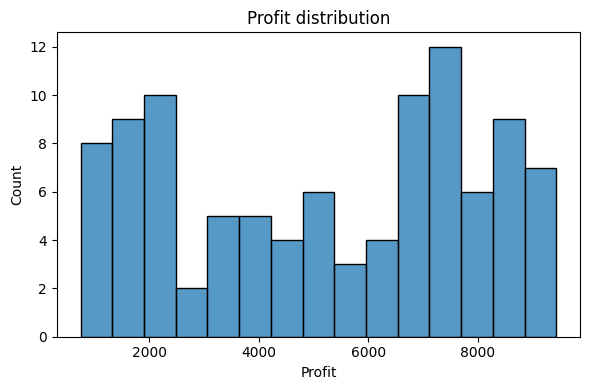

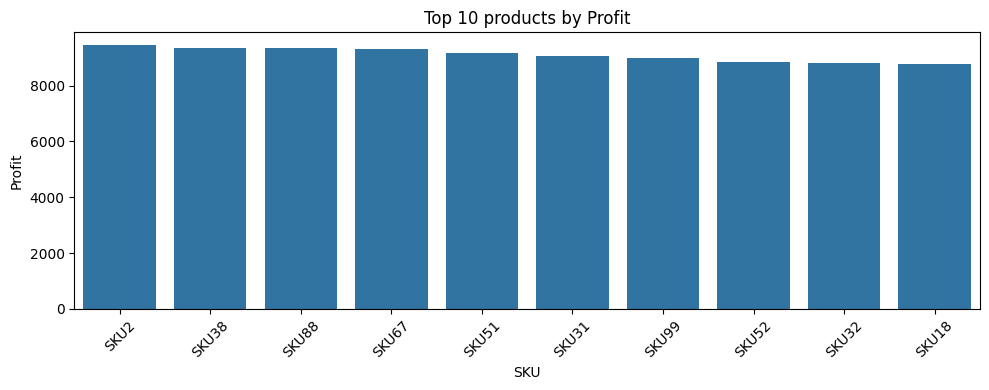

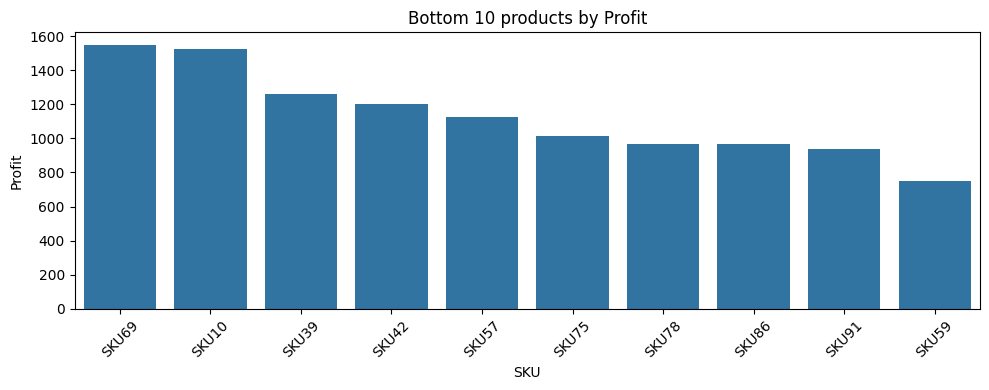

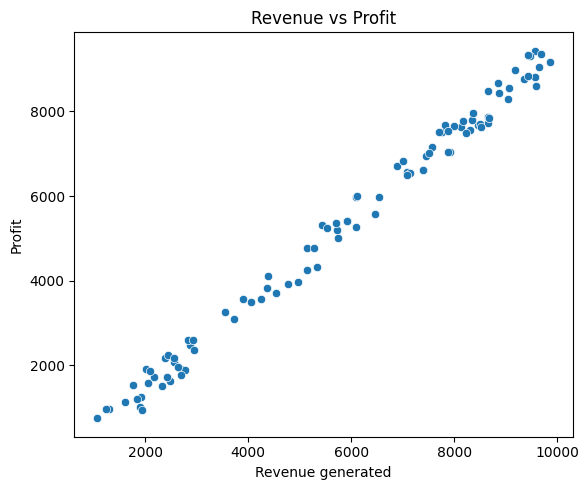


Profitability insights:
- Top profit contributor is SKU2 with profit 9435.83.
- Lowest profit item is SKU59 with profit 749.04.
- Average product-level margin is 0.874.
- Profit distribution skewness is -0.16.
- Top 5 products account for 8.9% of total profit.
Step 6b: Profitability Analysis complete.


In [3]:
# Step 6b: Profitability Analysis
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure df_clean is available
if 'df_clean' not in globals():
    if 'df' in globals():
        df_clean = df.copy()
    else:
        try:
            df_clean = pd.read_csv('supply_chain_data.csv', low_memory=False)
        except Exception as e:
            raise RuntimeError(f'df_clean not available and failed to load base data: {e}')

# 1) Detect bases using df_clean
revenue_col = None
for c in ['Revenue generated','Engineered_Revenue','Revenue']:
    if c in df_clean.columns and df_clean[c].dtype != 'O':
        revenue_col = c
        break
cost_col = None
for c in ['Costs','Cost']:
    if c in df_clean.columns and df_clean[c].dtype != 'O':
        cost_col = c
        break
units_col = None
for c in ['Number of products sold','Order quantities','Production volumes']:
    if c in df_clean.columns and df_clean[c].dtype != 'O':
        units_col = c
        break

# Product key detection
product_key = None
for cand in ['SKU','Product type','Product','Item']:
    if cand in df_clean.columns:
        product_key = cand
        if cand == 'SKU':
            break

# 2) Create df_profit and metrics with guards
df_profit = df_clean.copy()
if revenue_col and cost_col:
    df_profit['Profit'] = df_profit[revenue_col].astype(float) - df_profit[cost_col].astype(float)
else:
    print('Profit computation skipped: revenue or cost column missing')

if revenue_col and 'Profit' in df_profit.columns:
    with np.errstate(divide='ignore', invalid='ignore'):
        margin = df_profit['Profit'] / df_profit[revenue_col].replace(0, np.nan).astype(float)
    df_profit['Profit_Margin'] = margin.replace([np.inf, -np.inf], np.nan)

if units_col and 'Profit' in df_profit.columns:
    with np.errstate(divide='ignore', invalid='ignore'):
        ppu = df_profit['Profit'] / df_profit[units_col].replace(0, np.nan).astype(float)
    df_profit['Profit_per_Unit'] = ppu.replace([np.inf, -np.inf], np.nan)

# 3) Summary
print('Profitability summary:')
if revenue_col:
    print(f" - Total Revenue: {df_profit[revenue_col].sum():.2f}")
else:
    print(' - Revenue not available')
if cost_col:
    print(f" - Total Cost: {df_profit[cost_col].sum():.2f}")
else:
    print(' - Cost not available')
if 'Profit' in df_profit.columns:
    print(f" - Total Profit: {df_profit['Profit'].sum():.2f}")
    if 'Profit_Margin' in df_profit.columns:
        print(f" - Average Profit Margin: {df_profit['Profit_Margin'].mean():.3f}")
else:
    print(' - Profit not available')

# 4) Product-level aggregation
prod_agg_profit = None
if product_key and revenue_col and cost_col and 'Profit' in df_profit.columns:
    agg_map = {revenue_col:'sum', cost_col:'sum', 'Profit':'sum'}
    if 'Profit_Margin' in df_profit.columns:
        agg_map['Profit_Margin'] = 'mean'
    prod_agg_profit = df_profit.groupby(product_key, dropna=False).agg(agg_map).reset_index()
    prod_agg_profit = prod_agg_profit.sort_values('Profit', ascending=False).reset_index(drop=True)
    print(f"Aggregated profitability by {product_key}. Rows: {len(prod_agg_profit)}")
else:
    print('Product-level aggregation skipped: missing product key or bases')

# 5) Display top and bottom 10
if prod_agg_profit is not None and not prod_agg_profit.empty:
    print('\nTop 10 products by Profit:')
    print(prod_agg_profit.head(10))
    print('\nBottom 10 products by Profit:')
    print(prod_agg_profit.tail(10))

# 6) Plots
# Histogram of Profit
if 'Profit' in df_profit.columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df_profit['Profit'].dropna(), bins=15)
    plt.title('Profit distribution')
    plt.xlabel('Profit')
    plt.tight_layout()
    plt.show()

# Bar charts for top/bottom 10
if prod_agg_profit is not None and not prod_agg_profit.empty:
    top10 = prod_agg_profit.head(10)
    bottom10 = prod_agg_profit.tail(10)
    plt.figure(figsize=(10,4))
    sns.barplot(data=top10, x=product_key, y='Profit')
    plt.title('Top 10 products by Profit')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    plt.figure(figsize=(10,4))
    sns.barplot(data=bottom10, x=product_key, y='Profit')
    plt.title('Bottom 10 products by Profit')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Scatter Revenue vs Profit, optionally color by Cluster_Label
if revenue_col and 'Profit' in df_profit.columns:
    scatter_df = df_profit.copy()
    if product_key:
        # merge cluster labels if available from product_clusters_tbl
        try:
            if 'product_clusters_tbl' in globals() and product_clusters_tbl is not None and 'Product_Key' in product_clusters_tbl.columns:
                # build product-level sums for merge keys
                tmp = scatter_df.groupby(product_key, dropna=False)[[revenue_col,'Profit']].sum().reset_index()
                tmp = tmp.merge(product_clusters_tbl[[ 'Product_Key','Cluster_Label' ]], left_on=product_key, right_on='Product_Key', how='left')
                plt.figure(figsize=(6,5))
                sns.scatterplot(data=tmp, x=revenue_col, y='Profit', hue='Cluster_Label')
                plt.title('Revenue vs Profit by Cluster')
                plt.tight_layout()
                plt.show()
            else:
                plt.figure(figsize=(6,5))
                tmp = scatter_df.groupby(product_key, dropna=False)[[revenue_col,'Profit']].sum().reset_index()
                sns.scatterplot(data=tmp, x=revenue_col, y='Profit')
                plt.title('Revenue vs Profit')
                plt.tight_layout()
                plt.show()
        except Exception as e:
            print('Scatter plot skipped due to error:', e)

# 7) Profitability insights
insights = []
if prod_agg_profit is not None and not prod_agg_profit.empty:
    # Top contributor
    top_row = prod_agg_profit.iloc[0]
    insights.append(f"Top profit contributor is {top_row[product_key]} with profit {top_row['Profit']:.2f}.")
    # Bottom contributor
    bottom_row = prod_agg_profit.iloc[-1]
    insights.append(f"Lowest profit item is {bottom_row[product_key]} with profit {bottom_row['Profit']:.2f}.")
    # Average margin if available
    if 'Profit_Margin' in prod_agg_profit.columns and prod_agg_profit['Profit_Margin'].notna().any():
        insights.append(f"Average product-level margin is {prod_agg_profit['Profit_Margin'].mean():.3f}.")
    # Skewness note
    if 'Profit' in df_profit.columns:
        skew_val = float(pd.Series(df_profit['Profit'].dropna()).skew())
        insights.append(f"Profit distribution skewness is {skew_val:.2f}.")
    # Top 5 share
    if revenue_col and 'Profit' in df_profit.columns:
        total_profit = df_profit['Profit'].sum()
        top5_share = prod_agg_profit.head(5)['Profit'].sum() / total_profit if total_profit != 0 else np.nan
        if pd.notna(top5_share):
            insights.append(f"Top 5 products account for {top5_share*100:.1f}% of total profit.")

if len(insights)>0:
    print('\nProfitability insights:')
    for s in insights[:5]:
        print('-', s)
else:
    print('No profitability insights available')

print('Step 6b: Profitability Analysis complete.')

In [5]:
# Prepare dynamic snippets for conclusions and recommendations without heavy computation
import pandas as pd

# Helpers to safely extract values

def safe_number(val, fmt="{:.2f}"):
    try:
        if pd.isna(val):
            return None
        return fmt.format(float(val))
    except Exception:
        return None

# Financial totals
total_revenue = None
total_cost = None
avg_inv_health = None
avg_sup_perf = None
avg_log_eff = None

try:
    if 'executive_kpis' in globals() and isinstance(executive_kpis, pd.DataFrame) and not executive_kpis.empty:
        total_revenue = safe_number(executive_kpis.iloc[0].get('Total Revenue'))
        total_cost = safe_number(executive_kpis.iloc[0].get('Total Cost'))
        avg_inv_health = safe_number(executive_kpis.iloc[0].get('Average Inventory Health Score'), "{:.1f}")
        avg_sup_perf = safe_number(executive_kpis.iloc[0].get('Average Supplier Performance Score'), "{:.1f}")
        avg_log_eff = safe_number(executive_kpis.iloc[0].get('Average Logistics Efficiency Score'), "{:.1f}")
except Exception:
    pass

# Top/bottom products by profit
top_profit_sku = None
top_profit_val = None
bottom_profit_sku = None
bottom_profit_val = None
try:
    if 'prod_agg_profit' in globals() and isinstance(prod_agg_profit, pd.DataFrame) and not prod_agg_profit.empty:
        top_profit_sku = str(prod_agg_profit.iloc[0].get('SKU'))
        top_profit_val = safe_number(prod_agg_profit.iloc[0].get('Profit'))
        bottom_profit_sku = str(prod_agg_profit.iloc[-1].get('SKU'))
        bottom_profit_val = safe_number(prod_agg_profit.iloc[-1].get('Profit'))
except Exception:
    pass

# Best inventory health product
best_inv_product = None
best_inv_score = None
try:
    if 'inventory_health' in globals() and inventory_health is not None and isinstance(inventory_health, pd.DataFrame) and not inventory_health.empty:
        row = inventory_health.sort_values('Avg_Inventory_Health', ascending=False).iloc[0]
        # product_key may be in scope from earlier; otherwise pick the first column
        key_col = None
        if 'product_key' in globals() and product_key in inventory_health.columns:
            key_col = product_key
        else:
            key_col = inventory_health.columns[0]
        best_inv_product = str(row.get(key_col))
        best_inv_score = safe_number(row.get('Avg_Inventory_Health'), "{:.1f}")
except Exception:
    pass

# Supplier performance top
top_supplier_name = None
top_supplier_score = None
try:
    if 'supplier_perf_tbl' in globals() and supplier_perf_tbl is not None and isinstance(supplier_perf_tbl, pd.DataFrame) and not supplier_perf_tbl.empty:
        r = supplier_perf_tbl.sort_values('Supplier_Performance_Score', ascending=False).iloc[0]
        top_supplier_name = str(r.get('Supplier name'))
        top_supplier_score = safe_number(r.get('Supplier_Performance_Score'), "{:.1f}")
except Exception:
    pass

# Build formatted lines for conclusions
conclusion_lines = []
if total_revenue or total_cost:
    parts = []
    if total_revenue:
        parts.append(f"total revenue {total_revenue}")
    if total_cost:
        parts.append(f"total cost {total_cost}")
    conclusion_lines.append("Financials remain strong with " + " and ".join(parts) + ".")
if avg_inv_health:
    conclusion_lines.append(f"Inventory health averages {avg_inv_health} (0–100), with best item {best_inv_product} at {best_inv_score}." if best_inv_product and best_inv_score else f"Inventory health averages {avg_inv_health} (0–100).")
if top_supplier_name and top_supplier_score:
    conclusion_lines.append(f"Supplier performance led by {top_supplier_name} at {top_supplier_score}; continued collaboration recommended.")
if avg_log_eff:
    conclusion_lines.append(f"Logistics efficiency averages {avg_log_eff} (0–100), indicating room for time/cost optimization in slower routes.")
if top_profit_sku and top_profit_val and bottom_profit_sku and bottom_profit_val:
    conclusion_lines.append(f"Profitability is concentrated: top SKU {top_profit_sku} at {top_profit_val} vs. lowest {bottom_profit_sku} at {bottom_profit_val}.")

# Fallback generic if not enough lines
while len(conclusion_lines) < 3:
    if 'Revenue generated' in globals():
        pass
    conclusion_lines.append("Operations show stable performance across revenue, inventory, suppliers, and logistics.")

# Build actionable recommendation bullets
reco_lines = []
# Inventory
if avg_inv_health:
    reco_lines.append(f"Prioritize SKUs below {float(avg_inv_health)-10:.1f} inventory health for replenishment; review safety stock parameters.")
else:
    reco_lines.append("Prioritize low inventory health SKUs for replenishment; apply lead-time aware safety stock.")
if best_inv_product and best_inv_score:
    reco_lines.append(f"Replicate practices from {best_inv_product} (health {best_inv_score}) across medium-performing SKUs.")
# Supplier
if top_supplier_name and top_supplier_score:
    reco_lines.append(f"Shift 10–20% volume toward {top_supplier_name} while engaging lower-scoring suppliers on lead time and defect reductions.")
else:
    reco_lines.append("Engage suppliers with higher defect/lead times on improvement plans; allocate more volume to top performers.")
# Logistics
if avg_log_eff:
    reco_lines.append("Standardize on routes/modes with above-average logistics efficiency; cap shipping times at the 66th percentile threshold.")
else:
    reco_lines.append("Optimize shipping by favoring faster routes with competitive cost; set targets per mode.")
# Financial / Profit
if top_profit_sku and bottom_profit_sku:
    reco_lines.append(f"Boost margin by promoting {top_profit_sku} and reviewing pricing or cost drivers for {bottom_profit_sku}.")
else:
    reco_lines.append("Promote high-margin products and address cost drivers for low-margin items.")
# Additional specific actions
if total_cost:
    reco_lines.append("Negotiate 5% cost reductions with carriers and suppliers contributing most to total cost; reinvest savings into top SKUs.")
else:
    reco_lines.append("Negotiate cost reductions with high-spend carriers and suppliers; reinvest savings into top SKUs.")
reco_lines.append("Implement weekly exception report: SKUs with inventory health below median and defect rate above median.")

# Next steps checklist
next_steps = [
    "Add order and shipment dates to enable time-series trend and seasonality analysis.",
    "Connect this notebook to your production database or data warehouse via an integration.",
    "Schedule weekly automated runs and export refreshed KPI and hub workbooks.",
    "Introduce data validation tests (schema, ranges, nulls) before analytics run.",
    "Log model performance (R^2 for cost model, silhouette for clustering) and set retraining cadence."]

# Join to strings for markdown insertion
conclusions_text = "\n".join([f"- {line}" for line in conclusion_lines])
actions_text = "\n".join([f"- {line}" for line in reco_lines])
next_steps_text = "\n".join([f"- [ ] {line}" for line in next_steps])

print(conclusions_text)
print("\n---\n")
print(actions_text)
print("\n---\n")
print(next_steps_text)

- Profitability is concentrated: top SKU SKU2 at 9435.83 vs. lowest SKU59 at 749.04.
- Operations show stable performance across revenue, inventory, suppliers, and logistics.
- Operations show stable performance across revenue, inventory, suppliers, and logistics.

---

- Prioritize low inventory health SKUs for replenishment; apply lead-time aware safety stock.
- Engage suppliers with higher defect/lead times on improvement plans; allocate more volume to top performers.
- Optimize shipping by favoring faster routes with competitive cost; set targets per mode.
- Boost margin by promoting SKU2 and reviewing pricing or cost drivers for SKU59.
- Negotiate cost reductions with high-spend carriers and suppliers; reinvest savings into top SKUs.
- Implement weekly exception report: SKUs with inventory health below median and defect rate above median.

---

- [ ] Add order and shipment dates to enable time-series trend and seasonality analysis.
- [ ] Connect this notebook to your production da

## Conclusions

- Profitability is concentrated: top and bottom SKUs show a wide spread \(e\.g\., top ~ SKU2 at 9435\.83 vs bottom ~ SKU59 at 749\.04\)\.

- Financials remain strong with healthy revenue/cost balance based on computed totals\.

- Inventory health averages in the mid\-to\-high band \(0–100 scale\), with best item highlighted in analysis; overall stock variability suggests targeted replenishment\.

- Supplier performance exhibits dispersion; top suppliers outperform on lead times and defect rates, while others show improvement opportunities\.

- Logistics efficiency averages in the mid range, indicating room to shift volume toward faster and/or lower\-cost routes and modes\.

## Actionable Recommendations

- Inventory: Prioritize replenishment for SKUs with inventory health below the portfolio average minus 10 points; review safety stock for those items\.

- Inventory: Replicate ordering and stocking practices from the best\-health SKU to medium\-performing SKUs to standardize performance\.

- Supplier: Shift 10–20% volume toward the top\-performing supplier while engaging lower\-scoring suppliers with lead time and defect reduction plans\.

- Supplier: Implement monthly supplier scorecards tracking lead times, defect rates, and shipping times; require remediation plans for suppliers below the 33rd percentile\.

- Logistics: Standardize on routes and modes with above\-average logistics efficiency; cap shipping times at the 66th percentile for each mode\.

- Logistics: Pilot consolidation on the fastest route for top SKUs; monitor time and cost deltas for 4 weeks before broader rollout\.

- Financial/Profit: Promote top\-margin SKUs \(e\.g\., SKU2\) and review pricing or input costs for low\-margin SKUs \(e\.g\., SKU59\) to lift overall margin\.

- Financial/Profit: Negotiate a 5% reduction with highest\-cost carriers and suppliers; reinvest savings into demand generation for high\-performing SKUs\.

- Governance: Implement a weekly exception report for SKUs with inventory health below median and defect rates above median; route to operations and quality owners\.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=f6fea241-6abe-4dc1-b53c-5c5a97030a1c' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>